In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import random
import numpy as np
import copy
import matplotlib.pyplot as plt


import os
os.environ["CUDA_VISIBLE_DEVICES"]="0"

/gpu-data2/kfot/miniconda3/envs/myenv/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Set device (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [3]:
# Define the MLP model
class MLP(nn.Module):
    def __init__(self, input_size=784, hidden_size=256, num_classes=10, n_layers=4):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fcs = nn.ModuleList([nn.Linear(hidden_size, hidden_size) for _ in range(n_layers)])
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = x.view(-1, 784)  # Flatten the input for the fully connected layer
        x = self.fc1(x)
        x = self.relu(x)
        for layer in self.fcs:
            x = layer(x)
            x = self.relu(x)
        x = self.fc2(x)
        return x

class MaxoutLayer(nn.Module):
    def __init__(self, input_size, output_size, pool_size=2, aggregate='max'):
        super(MaxoutLayer, self).__init__()
        self.output_size = output_size
        self.pool_size = pool_size
        # Create two linear transformations for the maxout operation
        self.linear = nn.ModuleList([nn.Linear(input_size, output_size) for _ in range(pool_size)])

    def forward(self, x):
        # Apply each linear layer and stack the results
        maxout_layers = torch.stack([layer(x) for layer in self.linear], dim=2)  # Shape: (batch, output_size, pool_size)
        # Take the max across the pool_size dimension
        maxout_output = torch.max(maxout_layers, dim=2).values  # Shape: (batch, output_size)
        return maxout_output

class Maxout(nn.Module):
    def __init__(self, input_size=784, hidden_size=256, num_classes=10, n_layers=4):
        super(Maxout, self).__init__()
        self.maxout1 = MaxoutLayer(input_size, hidden_size, pool_size=2)
        self.maxouts = nn.ModuleList([MaxoutLayer(hidden_size, hidden_size) for _ in range(n_layers)])
        self.output = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = x.view(-1, 784)
        x = self.maxout1(x)
        for layer in self.maxouts:
            x = layer(x)
        x = self.output(x)
        return x

class MorphologicalLayer(nn.Module):
    def __init__(self, input_size, output_size, bias=True, method='max', l=None, alpha=1, beta=0):
        super(MorphologicalLayer, self).__init__()
        self.method = method
        self.bias = bias

        self.w = nn.Parameter(torch.randn(output_size, input_size)*alpha - beta)
        if bias:
            self.b = nn.Parameter(torch.randn(output_size))
            if method == 'max-plus-min' or method == 'dep':
                self.b2 = nn.Parameter(torch.randn(output_size))
        if method == 'dep':
            self.w2 = nn.Parameter(torch.randn(output_size, input_size)*alpha - beta)
            if l == None:
                self.l = nn.Parameter(torch.rand(output_size))
            else:
                self.l = l + torch.zeros(output_size).to(device)

    def forward(self, x, dropout=None):
        x = x.unsqueeze(1) 
        if dropout:
            mask = torch.rand(self.w.size(0), self.w.size(1)) < dropout
            mask = mask.to(device)
        if self.method == 'max':
            x = x + self.w
            if self.bias:
                x = torch.cat([x, self.b.view(1,-1,1).repeat(x.size(0),1,1)], dim=2)
            x, _ = torch.max(x, dim=2)  # Take max over the input dimension
        elif self.method == 'min':
            x = x + self.w
            if self.bias:
                x = torch.cat([x, self.b.view(1,-1,1).repeat(x.size(0),1,1)], dim=2)
            x, _ = torch.min(x, dim=2)
        elif self.method == 'max-plus-min':
            max_w = self.w
            min_w = self.w
            if dropout:
                max_w = max_w - mask * 1e9
                min_w = min_w + mask * 1e9
            x_max = x + max_w
            x_min = x + min_w
            if self.bias:
                x_max = torch.cat([x_max, self.b.view(1,-1,1).repeat(x.size(0),1,1)], dim=2)
                x_min = torch.cat([x_min, self.b2.view(1,-1,1).repeat(x.size(0),1,1)], dim=2)
            x_max, _ = torch.max(x_max, dim=2)
            x_min, _ = torch.min(x_min, dim=2)
            x = x_max + x_min
        elif self.method == 'dep':
            x_max = x + self.w
            x_min = x + self.w2
            if self.bias:
                x_max = torch.cat([x_max, self.b.view(1,-1,1).repeat(x_max.size(0),1,1)], dim=2)
                x_min = torch.cat([x_min, self.b2.view(1,-1,1).repeat(x_min.size(0),1,1)], dim=2)
            x_max, _ = torch.max(x_max, dim=2)
            x_min, _ = torch.min(x_min, dim=2)
            l = self.l.view(1,-1)
            l = torch.clamp(l, 0, 1)
            x = l * x_max + (1-l) * x_min
        return x
    
class LinAct(nn.Module):
    def __init__(self, size, method="simple"):
        super(LinAct, self).__init__()
        self.size = size
        self.method = method
        if method == "simple":
            self.a = nn.Parameter(torch.randn(size) / 3.46)
            # self.a = nn.Parameter(torch.rand(size)-0.5)
        else:
            tmp = nn.Linear(size, size, bias = False).weight.detach()
            U, S, Vh = np.linalg.svd(tmp.cpu().numpy(), full_matrices=True)
            self.U = torch.tensor(U).to(device)
            self.V = torch.tensor(Vh).t().to(device)
            self.a = torch.zeros(size).to(device)
            self.a[:S.shape[0]] = torch.tensor(S)
            self.a = nn.Parameter(self.a)

    def forward(self, x):
        if self.method == "simple":
            x = x * self.a.view(1, -1).repeat(x.size(0), 1)
        else:
            Smat = torch.diag(self.a)
            tmp = self.U @ Smat @ self.V.t()
            x = torch.mm(x, tmp.t())
        return x
    
# class Repeater(nn.Module):
#     def __init__(self, r):
#         super(Repeater, self).__init__()
#         self.r = r
#     def forward(self, x):
#         x = x.repeat(1, self.r)
#         return x
    
class MPM(nn.Module):
    def __init__(self, input_size=784, hidden_size=256, num_classes=10, n_layers=4):
        super(MPM, self).__init__()
        self.morph_layer1 = MorphologicalLayer(input_size, hidden_size, method='max-plus-min', alpha=0)
        self.linact1 = LinAct(hidden_size)
        self.morph_layers = nn.ModuleList([nn.Sequential(MorphologicalLayer(hidden_size, hidden_size, method='max-plus-min', alpha=1), LinAct(hidden_size)) for _ in range(n_layers)])
        self.morph_layer2 = MorphologicalLayer(hidden_size, num_classes, method='max-plus-min', alpha=1)

    def forward(self, x):
        x = x.view(-1, 784)  # Flatten input
        x = self.morph_layer1(x)
        x = self.linact1(x)
        for layer in self.morph_layers:
            x = layer(x)
        x = self.morph_layer2(x)
        return x

class RMPM(nn.Module):
    def __init__(self, input_size=784, hidden_size=256, num_classes=10, n_layers=4):
        super(RMPM, self).__init__()
        self.morph_layer1 = MorphologicalLayer(input_size, hidden_size, method='max-plus-min', alpha=0)
        self.linact1 = LinAct(hidden_size)
        self.morph_layers = nn.ModuleList([nn.Sequential(MorphologicalLayer(hidden_size, hidden_size, method='max-plus-min', alpha=1), LinAct(hidden_size)) for _ in range(n_layers)])
        self.morph_layer2 = MorphologicalLayer(hidden_size, num_classes, method='max-plus-min', alpha=1)

    def forward(self, x):
        x = x.view(-1, 784)  # Flatten input
        x = self.morph_layer1(x)
        x = self.linact1(x)
        for layer in self.morph_layers:
            x = x + layer(x)
        x = self.morph_layer2(x)
        return x

class RMPM_Drop(nn.Module):
    def __init__(self, input_size=784, hidden_size=256, num_classes=10, n_layers=4, dropout=0.5):
        super(RMPM_Drop, self).__init__()
        self.morph_layer1 = MorphologicalLayer(input_size, hidden_size, method='max-plus-min', alpha=0)
        self.linact1 = LinAct(hidden_size)
        self.morph_layers = nn.ModuleList([nn.Sequential(MorphologicalLayer(hidden_size, hidden_size, method='max-plus-min', alpha=1), LinAct(hidden_size)) for _ in range(n_layers)])
        self.morph_layer2 = MorphologicalLayer(hidden_size, num_classes, method='max-plus-min', alpha=1)

        self.dropout = dropout

    def forward(self, x):
        x = x.view(-1, 784)  # Flatten input
        if self.training:
            x = self.morph_layer1(x, self.dropout)
        else:
            x = self.morph_layer1(x)
        x = self.linact1(x)
        for layer in self.morph_layers:
            if self.training:
                x = x + layer[1](layer[0](x, self.dropout))
            else:
                x = x + layer(x)
        if self.training:
            x = self.morph_layer2(x, self.dropout)
        else:
            x = self.morph_layer2(x)
        return x
    
class MPM_SVD(nn.Module):
    def __init__(self, input_size=784, hidden_size=256, num_classes=10, n_layers=4):
        super(MPM_SVD, self).__init__()
        self.morph_layer1 = MorphologicalLayer(input_size, hidden_size, method='max-plus-min', alpha=0)
        self.linact1 = LinAct(hidden_size, method='svd')
        self.morph_layers = nn.ModuleList([nn.Sequential(MorphologicalLayer(hidden_size, hidden_size, method='max-plus-min', alpha=1), LinAct(hidden_size, method='svd')) for _ in range(n_layers)])
        self.morph_layer2 = MorphologicalLayer(hidden_size, num_classes, method='max-plus-min', alpha=1)

    def forward(self, x):
        x = x.view(-1, 784)  # Flatten input
        x = self.morph_layer1(x)
        x = self.linact1(x)
        for layer in self.morph_layers:
            x = layer(x)
        x = self.morph_layer2(x)
        return x

class HybridMLP(nn.Module):
    def __init__(self, input_size=784, hidden_size=256, num_classes=10, n_layers=4):
        super(HybridMLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.morph_layer1 = MorphologicalLayer(hidden_size, hidden_size, method='max-plus-min')
        self.layers = nn.ModuleList(
            [nn.Sequential(nn.Linear(hidden_size, hidden_size), 
                           MorphologicalLayer(hidden_size, hidden_size, method='max-plus-min'))
             for _ in range(n_layers)]
            )
        self.fc2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = x.view(-1, 784)  # Flatten input
        x = self.fc1(x)
        x = self.morph_layer1(x)
        for layer in self.layers:
            x = layer(x)
        x = self.fc2(x)
        return x
    
class MP(nn.Module):
    def __init__(self, input_size=784, hidden_size=256, num_classes=10, n_layers=4):
        super(MP, self).__init__()
        self.morph_layer1 = MorphologicalLayer(input_size, hidden_size, method='max', alpha=0, beta=1)
        self.morph_layers = nn.ModuleList([nn.Sequential(MorphologicalLayer(hidden_size, hidden_size, method='max', alpha=3, beta=5)) for _ in range(n_layers)])
        self.morph_layer2 = MorphologicalLayer(hidden_size, num_classes, method='max', alpha=3, beta=5)

    def forward(self, x):
        x = x.view(-1, 784)  # Flatten input
        x = self.morph_layer1(x)
        for layer in self.morph_layers:
            x = layer(x)
        x = self.morph_layer2(x)
        return x
    
class Act_MP(nn.Module):
    def __init__(self, input_size=784, hidden_size=256, num_classes=10, n_layers=4):
        super(Act_MP, self).__init__()
        self.morph_layer1 = MorphologicalLayer(input_size, hidden_size, method='max', alpha=0, beta=1)
        self.linact1 = LinAct(hidden_size)
        self.morph_layers = nn.ModuleList([nn.Sequential(MorphologicalLayer(hidden_size, hidden_size, method='max', alpha=3, beta=5), LinAct(hidden_size)) for _ in range(n_layers)])
        self.morph_layer2 = MorphologicalLayer(hidden_size, num_classes, method='max', alpha=3, beta=5)

    def forward(self, x):
        x = x.view(-1, 784)  # Flatten input
        x = self.morph_layer1(x)
        x = self.linact1(x)
        for layer in self.morph_layers:
            x = layer(x)
        x = self.morph_layer2(x)
        return x
    
class DEP(nn.Module):
    def __init__(self, input_size=784, hidden_size=256, num_classes=10, n_layers=4, l=None):
        super(DEP, self).__init__()
        self.morph_layer1 = MorphologicalLayer(input_size, hidden_size, bias=False, method='dep', l=l, alpha=0)
        self.morph_layers = nn.ModuleList([nn.Sequential(MorphologicalLayer(hidden_size, hidden_size, bias=False, method='dep', l=l, alpha=1)) for _ in range(n_layers)])
        self.morph_layer2 = MorphologicalLayer(hidden_size, num_classes, bias=False, method='dep', l=l, alpha=1)

    def forward(self, x):
        x = x.view(-1, 784)  # Flatten input
        x = self.morph_layer1(x)
        for layer in self.morph_layers:
            x = layer(x)
        x = self.morph_layer2(x)
        return x
    
class Act_DEP(nn.Module):
    def __init__(self, input_size=784, hidden_size=256, num_classes=10, n_layers=4, l=None):
        super(Act_DEP, self).__init__()
        self.morph_layer1 = MorphologicalLayer(input_size, hidden_size, bias=False, method='dep', l=l, alpha=0)
        self.linact1 = LinAct(hidden_size)
        self.morph_layers = nn.ModuleList([nn.Sequential(MorphologicalLayer(hidden_size, hidden_size, bias=False, method='dep', l=l, alpha=1), LinAct(hidden_size)) for _ in range(n_layers)])
        self.morph_layer2 = MorphologicalLayer(hidden_size, num_classes, bias = False, method='dep', l=l, alpha=1)

    def forward(self, x):
        x = x.view(-1, 784)  # Flatten input
        x = self.morph_layer1(x)
        x = self.linact1(x)
        for layer in self.morph_layers:
            x = layer(x)
        x = self.morph_layer2(x)
        return x

class MinMaxPlus(nn.Module):
    def __init__(self, input_size=784, hidden_size=256, num_classes=10, n_layers=4):
        super(MinMaxPlus, self).__init__()
        self.multipliers = LinAct(input_size, method="simple")
        self.morph_layer1 = nn.Sequential( 
            MorphologicalLayer(2*input_size, hidden_size, bias=False, method='max'), 
            MorphologicalLayer(2*hidden_size, hidden_size, bias=False, method='min')
        )
        self.morph_layers = nn.ModuleList([
            nn.Sequential(
                MorphologicalLayer(hidden_size, hidden_size, bias=False, method='max'), 
                MorphologicalLayer(hidden_size, hidden_size, bias=False, method='min')
            ) 
            for _ in range(n_layers)
            ]
        )
        self.morph_layer2 = nn.Sequential(
            MorphologicalLayer(hidden_size, hidden_size, bias=False, method='max'), 
            MorphologicalLayer(hidden_size, num_classes, bias=False, method='min')
        )

    def forward(self, x):
        x = x.view(-1, 784)  # Flatten input
        x = self.multipliers(x)
        x = self.morph_layer1(x)
        for layer in self.morph_layers:
            x = layer(x)
        x = self.morph_layer2(x)
        return x

class Negator(nn.Module):
    def __init__(self):
        super(Negator, self).__init__()
    def forward(self, x):
        x = torch.cat([x, -x], dim=-1)
        return x

class MinMaxPlus_neg(nn.Module):
    def __init__(self, input_size=784, hidden_size=256, num_classes=10, n_layers=4):
        super(MinMaxPlus_neg, self).__init__()
        self.multipliers = LinAct(input_size, method="simple")
        self.morph_layer1 = nn.Sequential( 
            Negator(), 
            MorphologicalLayer(2*input_size, hidden_size, bias=False, method='max'), 
            MorphologicalLayer(hidden_size, hidden_size, bias=False, method='min')
        )
        self.morph_layers = nn.ModuleList([
            nn.Sequential(
                Negator(), 
                MorphologicalLayer(2*hidden_size, hidden_size, bias=False, method='max'), 
                MorphologicalLayer(hidden_size, hidden_size, bias=False, method='min')
            ) 
            for _ in range(n_layers)
            ]
        )
        self.morph_layer2 = nn.Sequential(
            Negator(), 
            MorphologicalLayer(2*hidden_size, hidden_size, bias=False, method='max'), 
            MorphologicalLayer(hidden_size, num_classes, bias=False, method='min')
        )

    def forward(self, x):
        x = x.view(-1, 784)  # Flatten input
        x = self.multipliers(x)
        x = self.morph_layer1(x)
        for layer in self.morph_layers:
            x = layer(x)
        x = self.morph_layer2(x)
        return x

    
class MorphConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=(3,3), stride=(1,1), padding=(1,1), bias=True, method="max-plus-min", alpha=1.0):
        super(MorphConv2d, self).__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding
        self.bias = bias
        self.method = method
        self.alpha = alpha

        self.weight = nn.Parameter(
            torch.normal(mean=0.0, std=alpha, size=(out_channels, in_channels, kernel_size[0], kernel_size[1]))
        )
        if bias:
            self.b = nn.Parameter(torch.normal(mean=0.0, std=1.0, size=(out_channels, )))
            self.b2 = nn.Parameter(torch.normal(mean=0.0, std=1.0, size=(out_channels, )))

    def forward(self, x):
        # Max morphological operation
        x_max = torch.exp(x)
        w_max = torch.exp(self.weight)
        if self.bias:
            b_max = torch.exp(self.b)
            x_max = F.conv2d(x_max, w_max, b_max, stride=self.stride, padding=self.padding)
        else:
            x_max = F.conv2d(x_max, w_max, stride=self.stride, padding=self.padding)
        x_max = torch.log(x_max)

        # Min morphological operation
        x_min = torch.exp(-x)
        w_min = torch.exp(-self.weight)
        if self.bias:
            b_min = torch.exp(-self.b2)
            x_min = F.conv2d(x_min, w_min, b_min, stride=self.stride, padding=self.padding)
        else:
            x_min = F.conv2d(x_min, w_min, stride=self.stride, padding=self.padding)
        x_min = -torch.log(x_min)

        # Aggregation of max and min operations
        if self.method == "max":
            x_out = x_max
        elif self.method == "min":
            x_out = x_min
        else:
            x_out = x_max + x_min

        return x_out
    
class ConvLinAct(nn.Module):
    def __init__(self, channels, method="simple"):
        super(ConvLinAct, self).__init__()
        self.method = method

        if method == 'simple':
            # self.a = nn.Parameter(torch.randn(channels, size, size)/3.46)
            # self.a = nn.Parameter(torch.rand(channels)-0.5)
            self.a = nn.Parameter(torch.randn(3, 3, channels))
        else:
            tmp = nn.Conv2d(channels, channels, 3, bias = False).weight.data.detach()
            tmp = torch.transpose(tmp, 0, 2)
            tmp = torch.transpose(tmp, 1, 3)
            U, S, Vh = np.linalg.svd(tmp.cpu().numpy(), full_matrices=True)
            self.U = torch.tensor(U).to(device)
            self.Vh = torch.tensor(Vh).to(device)
            self.a = torch.zeros(3, 3, channels).to(device)
            self.a[:, :, :S.shape[2]] = torch.tensor(S)
            self.a = nn.Parameter(self.a)
    def forward(self, x):
        if self.method == 'simple':
            # x = x * self.a.unsqueeze(-1).unsqueeze(-1).unsqueeze(0).repeat(x.size(0), 1, x.size(2), x.size(3))
            tmp = torch.diag_embed(self.a)
            tmp = torch.transpose(tmp, 0, 2)
            tmp = torch.transpose(tmp, 1, 3)
            x = nn.functional.conv2d(x, tmp, padding=1)
        else:
            tmp = self.U @ (self.a.unsqueeze(-1) * self.Vh)
            tmp = torch.transpose(tmp, 0, 2)
            tmp = torch.transpose(tmp, 1, 3)
            x = nn.functional.conv2d(x, tmp, padding=1)
        return x
    
class MPM_LeNet5(nn.Module):
    def __init__(self, n_classes=10):
        super(MPM_LeNet5, self).__init__()
                  
        self.conv1 = MorphConv2d(in_channels=1, out_channels=6, kernel_size=(5,5), padding = 1, method='max-plus-min', alpha=0.001)
        self.linact1 = ConvLinAct(6, method="simple")
        self.conv2 = MorphConv2d(in_channels=6, out_channels=16, kernel_size=(5,5), padding = 1, method='max-plus-min')
        self.linact2 = ConvLinAct(16, method="simple")
        self.conv3 = MorphConv2d(in_channels=16, out_channels=120, kernel_size=(5,5), padding = 1, method='max-plus-min')
        self.linact3 = ConvLinAct(120, method="simple")
        self.maxpool = nn.MaxPool2d(kernel_size=2)

        self.morph_layer1 = MorphologicalLayer(input_size=120, output_size=84, bias=True, method='max-plus-min')
        self.linact4 = LinAct(84)
        self.morph_layer2 = MorphologicalLayer(input_size=84, output_size=n_classes, bias=True, method='max-plus-min')

    def forward(self, x):
        x = self.conv1(x)
        x = self.linact1(x)
        x = self.maxpool(x)
        x = self.conv2(x)
        x = self.linact2(x)
        x = self.maxpool(x)
        x = self.conv3(x)
        x = self.linact3(x)
        x = self.maxpool(x)

        x = torch.flatten(x, 1)
        
        x = self.morph_layer1(x)
        x = self.linact4(x)
        x = self.morph_layer2(x)
        return x

class MPM_SVD_LeNet5(nn.Module):
    def __init__(self, n_classes=10):
        super(MPM_SVD_LeNet5, self).__init__()
                  
        self.conv1 = MorphConv2d(in_channels=1, out_channels=6, kernel_size=(5,5), padding = 1, method='max-plus-min', alpha=0.001)
        self.linact1 = ConvLinAct(6, method="svd")
        self.conv2 = MorphConv2d(in_channels=6, out_channels=16, kernel_size=(5,5), padding = 1, method='max-plus-min')
        self.linact2 = ConvLinAct(16, method="svd")
        self.conv3 = MorphConv2d(in_channels=16, out_channels=120, kernel_size=(5,5), padding = 1, method='max-plus-min')
        self.linact3 = ConvLinAct(120, method="svd")
        self.maxpool = nn.MaxPool2d(kernel_size=2)

        self.morph_layer1 = MorphologicalLayer(input_size=120, output_size=84, bias=True, method='max-plus-min')
        self.linact4 = LinAct(84, method="svd")
        self.morph_layer2 = MorphologicalLayer(input_size=84, output_size=n_classes, bias=True, method='max-plus-min')

    def forward(self, x):
        x = self.conv1(x)
        x = self.linact1(x)
        x = self.maxpool(x)
        x = self.conv2(x)
        x = self.linact2(x)
        x = self.maxpool(x)
        x = self.conv3(x)
        x = self.linact3(x)
        x = self.maxpool(x)

        x = torch.flatten(x, 1)
        
        x = self.morph_layer1(x)
        x = self.linact4(x)
        x = self.morph_layer2(x)
        return x

class LeNet5(nn.Module):
    def __init__(self, n_classes=10):
        super(LeNet5, self).__init__()
                  
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5, padding = 1)
        self.conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5, padding = 1)
        self.conv3 = nn.Conv2d(in_channels=16, out_channels=120, kernel_size=5, padding = 1)
        self.relu = nn.ReLU()
        self.maxpool = nn.MaxPool2d(kernel_size=2)

        self.layer1 = nn.Linear(120, 84)
        self.layer2 = nn.Linear(84, n_classes, bias=False)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = self.conv2(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = self.conv3(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = torch.flatten(x, 1)
        
        x = self.layer1(x)
        x = self.relu(x)
        x = self.layer2(x)
        return x
    

In [4]:
def train(model, criterion, optimizer, train_loader, val_loader, num_epochs=50, return_list=False):
    # Training and validation loop
    best_val_accuracy = 0.0
    best_model = None

    train_list = []
    val_list = []

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward pass and optimization
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # Validation phase
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in train_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        train_accuracy = 100 * correct / total
        train_list.append(train_accuracy)
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_accuracy = 100 * correct / total
        val_list.append(val_accuracy)
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}, Train Accuracy: {train_accuracy:.2f}%, Validation Accuracy: {val_accuracy:.2f}%")

        # Save best model based on validation accuracy
        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            best_model = copy.deepcopy(model)

    if return_list:
        return best_model, train_list, val_list
    else:
        return best_model

def test(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f'Accuracy on the test set: {accuracy:.2f}%')

In [5]:
# Load and preprocess MNIST dataset
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

full_train_dataset = torchvision.datasets.MNIST(root='../data', train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.MNIST(root='../data', train=False, transform=transform, download=True)

# Split train dataset into training and validation sets
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# Data loaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [66]:
# Initialize model, loss function, and optimizer
model = MLP().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 466698
Epoch [1/50], Loss: 0.1998, Train Accuracy: 93.74%, Validation Accuracy: 93.49%
Epoch [2/50], Loss: 0.1242, Train Accuracy: 92.63%, Validation Accuracy: 91.95%
Epoch [3/50], Loss: 0.0884, Train Accuracy: 96.62%, Validation Accuracy: 96.22%
Epoch [4/50], Loss: 0.0672, Train Accuracy: 97.70%, Validation Accuracy: 97.25%
Epoch [5/50], Loss: 0.1107, Train Accuracy: 97.75%, Validation Accuracy: 96.83%
Epoch [6/50], Loss: 0.0475, Train Accuracy: 98.32%, Validation Accuracy: 97.53%
Epoch [7/50], Loss: 0.0518, Train Accuracy: 98.00%, Validation Accuracy: 97.18%
Epoch [8/50], Loss: 0.0221, Train Accuracy: 98.05%, Validation Accuracy: 97.03%
Epoch [9/50], Loss: 0.0219, Train Accuracy: 97.07%, Validation Accuracy: 96.17%
Epoch [10/50], Loss: 0.0183, Train Accuracy: 98.63%, Validation Accuracy: 97.34%
Epoch [11/50], Loss: 0.1168, Train Accuracy: 98.64%, Validation Accuracy: 97.38%
Epoch [12/50], Loss: 0.0828, Train Accuracy: 98.55%, Validation Accuracy: 97.06%
Ep

In [67]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 98.12%


In [69]:
# Initialize model, loss function, and optimizer
model = MP().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 466698
Epoch [1/50], Loss: 2.2816, Train Accuracy: 11.48%, Validation Accuracy: 10.90%
Epoch [2/50], Loss: 2.1893, Train Accuracy: 24.67%, Validation Accuracy: 24.34%
Epoch [3/50], Loss: 2.1692, Train Accuracy: 24.93%, Validation Accuracy: 24.66%
Epoch [4/50], Loss: 2.1334, Train Accuracy: 27.32%, Validation Accuracy: 27.17%
Epoch [5/50], Loss: 2.1291, Train Accuracy: 26.21%, Validation Accuracy: 26.10%
Epoch [6/50], Loss: 2.1141, Train Accuracy: 31.43%, Validation Accuracy: 31.30%
Epoch [7/50], Loss: 2.0415, Train Accuracy: 26.05%, Validation Accuracy: 25.98%
Epoch [8/50], Loss: 2.1089, Train Accuracy: 26.88%, Validation Accuracy: 26.83%
Epoch [9/50], Loss: 2.1064, Train Accuracy: 27.00%, Validation Accuracy: 26.93%
Epoch [10/50], Loss: 2.1003, Train Accuracy: 32.15%, Validation Accuracy: 32.13%
Epoch [11/50], Loss: 2.0116, Train Accuracy: 27.29%, Validation Accuracy: 27.32%
Epoch [12/50], Loss: 2.1367, Train Accuracy: 27.39%, Validation Accuracy: 27.52%
Ep

In [70]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 33.00%


In [71]:
# Initialize model, loss function, and optimizer
model = DEP().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 932106
Epoch [1/50], Loss: 2.2167, Train Accuracy: 26.52%, Validation Accuracy: 25.83%
Epoch [2/50], Loss: 2.0031, Train Accuracy: 37.54%, Validation Accuracy: 37.37%
Epoch [3/50], Loss: 1.8553, Train Accuracy: 48.95%, Validation Accuracy: 49.00%
Epoch [4/50], Loss: 1.8260, Train Accuracy: 52.19%, Validation Accuracy: 52.01%
Epoch [5/50], Loss: 1.7334, Train Accuracy: 52.64%, Validation Accuracy: 53.24%
Epoch [6/50], Loss: 1.7300, Train Accuracy: 52.13%, Validation Accuracy: 52.48%
Epoch [7/50], Loss: 1.6994, Train Accuracy: 54.37%, Validation Accuracy: 54.65%
Epoch [8/50], Loss: 1.6411, Train Accuracy: 59.72%, Validation Accuracy: 60.06%
Epoch [9/50], Loss: 1.6289, Train Accuracy: 61.67%, Validation Accuracy: 62.61%
Epoch [10/50], Loss: 1.6279, Train Accuracy: 63.11%, Validation Accuracy: 63.76%
Epoch [11/50], Loss: 1.5363, Train Accuracy: 62.84%, Validation Accuracy: 63.17%
Epoch [12/50], Loss: 1.6405, Train Accuracy: 63.85%, Validation Accuracy: 64.30%
Ep

In [72]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 71.79%


In [6]:
# Initialize model, loss function, and optimizer
model = DEP(l=1/2).to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 930816
Epoch [1/50], Loss: 2.1946, Train Accuracy: 44.73%, Validation Accuracy: 44.31%
Epoch [2/50], Loss: 2.0800, Train Accuracy: 49.66%, Validation Accuracy: 49.48%
Epoch [3/50], Loss: 2.0099, Train Accuracy: 56.23%, Validation Accuracy: 55.98%
Epoch [4/50], Loss: 2.0230, Train Accuracy: 58.75%, Validation Accuracy: 58.47%
Epoch [5/50], Loss: 1.9199, Train Accuracy: 62.70%, Validation Accuracy: 62.38%
Epoch [6/50], Loss: 1.9294, Train Accuracy: 64.16%, Validation Accuracy: 63.90%
Epoch [7/50], Loss: 1.9241, Train Accuracy: 66.73%, Validation Accuracy: 66.28%
Epoch [8/50], Loss: 1.8140, Train Accuracy: 65.52%, Validation Accuracy: 65.23%
Epoch [9/50], Loss: 1.9161, Train Accuracy: 68.43%, Validation Accuracy: 68.46%
Epoch [10/50], Loss: 1.8951, Train Accuracy: 67.64%, Validation Accuracy: 67.26%
Epoch [11/50], Loss: 1.8912, Train Accuracy: 69.81%, Validation Accuracy: 69.70%
Epoch [12/50], Loss: 1.8438, Train Accuracy: 69.22%, Validation Accuracy: 69.03%
Ep

In [7]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 76.89%


In [63]:
# Initialize model, loss function, and optimizer
model = Act_MP().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 467978
Epoch [1/50], Loss: 2.3385, Train Accuracy: 17.59%, Validation Accuracy: 17.54%
Epoch [2/50], Loss: 2.1185, Train Accuracy: 30.21%, Validation Accuracy: 30.95%
Epoch [3/50], Loss: 1.7981, Train Accuracy: 40.76%, Validation Accuracy: 41.37%
Epoch [4/50], Loss: 1.5310, Train Accuracy: 45.45%, Validation Accuracy: 45.95%
Epoch [5/50], Loss: 1.4793, Train Accuracy: 54.87%, Validation Accuracy: 55.88%
Epoch [6/50], Loss: 1.4333, Train Accuracy: 50.58%, Validation Accuracy: 51.23%
Epoch [7/50], Loss: 1.3111, Train Accuracy: 53.84%, Validation Accuracy: 54.01%
Epoch [8/50], Loss: 1.1736, Train Accuracy: 59.35%, Validation Accuracy: 59.08%
Epoch [9/50], Loss: 1.1508, Train Accuracy: 60.36%, Validation Accuracy: 60.12%
Epoch [10/50], Loss: 1.0293, Train Accuracy: 70.73%, Validation Accuracy: 70.66%
Epoch [11/50], Loss: 0.8547, Train Accuracy: 71.63%, Validation Accuracy: 71.64%
Epoch [12/50], Loss: 0.7666, Train Accuracy: 72.67%, Validation Accuracy: 72.65%
Ep

In [64]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 78.78%


In [75]:
# Initialize model, loss function, and optimizer
model = Act_DEP().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 933386
Epoch [1/50], Loss: 2.2933, Train Accuracy: 11.29%, Validation Accuracy: 11.04%
Epoch [2/50], Loss: 2.0163, Train Accuracy: 37.60%, Validation Accuracy: 37.92%
Epoch [3/50], Loss: 1.6990, Train Accuracy: 56.75%, Validation Accuracy: 56.27%
Epoch [4/50], Loss: 1.2137, Train Accuracy: 63.51%, Validation Accuracy: 62.59%
Epoch [5/50], Loss: 1.1888, Train Accuracy: 65.76%, Validation Accuracy: 65.42%
Epoch [6/50], Loss: 1.1018, Train Accuracy: 69.35%, Validation Accuracy: 69.44%
Epoch [7/50], Loss: 1.0386, Train Accuracy: 71.84%, Validation Accuracy: 71.23%
Epoch [8/50], Loss: 0.7589, Train Accuracy: 72.69%, Validation Accuracy: 72.32%
Epoch [9/50], Loss: 0.9241, Train Accuracy: 73.76%, Validation Accuracy: 73.40%
Epoch [10/50], Loss: 0.9571, Train Accuracy: 74.72%, Validation Accuracy: 74.31%
Epoch [11/50], Loss: 0.8356, Train Accuracy: 75.47%, Validation Accuracy: 75.30%
Epoch [12/50], Loss: 0.6682, Train Accuracy: 75.85%, Validation Accuracy: 75.68%
Ep

In [76]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 83.44%


In [77]:
# Initialize model, loss function, and optimizer
model = Act_DEP(l=3/4).to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 932096
Epoch [1/50], Loss: 2.2663, Train Accuracy: 19.16%, Validation Accuracy: 19.06%
Epoch [2/50], Loss: 1.6265, Train Accuracy: 54.95%, Validation Accuracy: 55.13%
Epoch [3/50], Loss: 1.1123, Train Accuracy: 70.49%, Validation Accuracy: 70.35%
Epoch [4/50], Loss: 1.0148, Train Accuracy: 74.53%, Validation Accuracy: 74.38%
Epoch [5/50], Loss: 0.6361, Train Accuracy: 78.37%, Validation Accuracy: 78.29%
Epoch [6/50], Loss: 0.7189, Train Accuracy: 80.41%, Validation Accuracy: 80.04%
Epoch [7/50], Loss: 0.5662, Train Accuracy: 81.62%, Validation Accuracy: 81.28%
Epoch [8/50], Loss: 0.6169, Train Accuracy: 83.34%, Validation Accuracy: 82.73%
Epoch [9/50], Loss: 0.5181, Train Accuracy: 84.49%, Validation Accuracy: 84.27%
Epoch [10/50], Loss: 0.6846, Train Accuracy: 85.87%, Validation Accuracy: 85.46%
Epoch [11/50], Loss: 0.6111, Train Accuracy: 86.63%, Validation Accuracy: 86.07%
Epoch [12/50], Loss: 0.3002, Train Accuracy: 87.71%, Validation Accuracy: 87.12%
Ep

In [78]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 92.23%


In [22]:
# Initialize model, loss function, and optimizer
model = Act_DEP(l=1/2).to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 932096
Epoch [1/50], Loss: 2.1577, Train Accuracy: 56.03%, Validation Accuracy: 56.33%
Epoch [2/50], Loss: 0.6400, Train Accuracy: 84.13%, Validation Accuracy: 84.05%
Epoch [3/50], Loss: 0.4378, Train Accuracy: 88.25%, Validation Accuracy: 87.88%
Epoch [4/50], Loss: 0.5213, Train Accuracy: 90.18%, Validation Accuracy: 89.85%
Epoch [5/50], Loss: 0.1483, Train Accuracy: 91.72%, Validation Accuracy: 91.18%
Epoch [6/50], Loss: 0.3442, Train Accuracy: 92.69%, Validation Accuracy: 91.71%
Epoch [7/50], Loss: 0.3399, Train Accuracy: 93.53%, Validation Accuracy: 92.30%
Epoch [8/50], Loss: 0.3434, Train Accuracy: 94.18%, Validation Accuracy: 92.73%
Epoch [9/50], Loss: 0.2179, Train Accuracy: 94.58%, Validation Accuracy: 93.01%
Epoch [10/50], Loss: 0.1481, Train Accuracy: 95.01%, Validation Accuracy: 93.38%
Epoch [11/50], Loss: 0.1185, Train Accuracy: 95.38%, Validation Accuracy: 93.50%
Epoch [12/50], Loss: 0.1864, Train Accuracy: 95.72%, Validation Accuracy: 93.67%
Ep

In [23]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 94.75%


In [12]:
# Initialize model, loss function, and optimizer
model = MinMaxPlus().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 859408
Epoch [1/50], Loss: 1.9854, Train Accuracy: 44.21%, Validation Accuracy: 43.60%
Epoch [2/50], Loss: 1.8091, Train Accuracy: 51.83%, Validation Accuracy: 51.46%
Epoch [3/50], Loss: 1.6613, Train Accuracy: 54.78%, Validation Accuracy: 54.09%
Epoch [4/50], Loss: 1.5227, Train Accuracy: 56.62%, Validation Accuracy: 56.08%
Epoch [5/50], Loss: 1.6312, Train Accuracy: 57.79%, Validation Accuracy: 57.41%
Epoch [6/50], Loss: 1.5336, Train Accuracy: 58.41%, Validation Accuracy: 57.95%
Epoch [7/50], Loss: 1.4598, Train Accuracy: 59.73%, Validation Accuracy: 58.92%
Epoch [8/50], Loss: 1.3567, Train Accuracy: 60.07%, Validation Accuracy: 59.37%
Epoch [9/50], Loss: 1.3685, Train Accuracy: 60.98%, Validation Accuracy: 60.35%
Epoch [10/50], Loss: 1.4284, Train Accuracy: 61.15%, Validation Accuracy: 60.52%
Epoch [11/50], Loss: 1.4466, Train Accuracy: 61.77%, Validation Accuracy: 61.14%
Epoch [12/50], Loss: 1.2267, Train Accuracy: 63.06%, Validation Accuracy: 62.48%
Ep

In [13]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 76.80%


In [6]:
# Initialize model, loss function, and optimizer
model = MinMaxPlus_neg().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 1387792
Epoch [1/50], Loss: 2.0223, Train Accuracy: 49.02%, Validation Accuracy: 49.87%
Epoch [2/50], Loss: 1.8981, Train Accuracy: 51.04%, Validation Accuracy: 51.73%
Epoch [3/50], Loss: 1.7385, Train Accuracy: 53.61%, Validation Accuracy: 54.40%
Epoch [4/50], Loss: 1.6140, Train Accuracy: 54.69%, Validation Accuracy: 55.56%
Epoch [5/50], Loss: 1.6919, Train Accuracy: 56.69%, Validation Accuracy: 57.83%
Epoch [6/50], Loss: 1.5354, Train Accuracy: 57.58%, Validation Accuracy: 58.68%
Epoch [7/50], Loss: 1.5669, Train Accuracy: 58.14%, Validation Accuracy: 58.98%
Epoch [8/50], Loss: 1.4412, Train Accuracy: 59.39%, Validation Accuracy: 60.14%
Epoch [9/50], Loss: 1.5077, Train Accuracy: 60.45%, Validation Accuracy: 61.05%
Epoch [10/50], Loss: 1.3612, Train Accuracy: 61.23%, Validation Accuracy: 61.72%
Epoch [11/50], Loss: 1.4011, Train Accuracy: 62.09%, Validation Accuracy: 62.38%
Epoch [12/50], Loss: 1.2062, Train Accuracy: 62.84%, Validation Accuracy: 63.08%
E

In [7]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 73.68%


In [17]:
# Initialize model, loss function, and optimizer
model = MPM().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 469268
Epoch [1/50], Loss: 0.8505, Train Accuracy: 85.83%, Validation Accuracy: 85.85%
Epoch [2/50], Loss: 0.1896, Train Accuracy: 91.19%, Validation Accuracy: 90.55%
Epoch [3/50], Loss: 0.3388, Train Accuracy: 93.21%, Validation Accuracy: 92.35%
Epoch [4/50], Loss: 0.2343, Train Accuracy: 94.34%, Validation Accuracy: 93.22%
Epoch [5/50], Loss: 0.1830, Train Accuracy: 95.01%, Validation Accuracy: 93.62%
Epoch [6/50], Loss: 0.0697, Train Accuracy: 95.65%, Validation Accuracy: 94.01%
Epoch [7/50], Loss: 0.0766, Train Accuracy: 96.11%, Validation Accuracy: 94.12%
Epoch [8/50], Loss: 0.0769, Train Accuracy: 96.58%, Validation Accuracy: 94.36%
Epoch [9/50], Loss: 0.1714, Train Accuracy: 96.88%, Validation Accuracy: 94.61%
Epoch [10/50], Loss: 0.0870, Train Accuracy: 97.16%, Validation Accuracy: 94.78%
Epoch [11/50], Loss: 0.0764, Train Accuracy: 97.44%, Validation Accuracy: 94.84%
Epoch [12/50], Loss: 0.1341, Train Accuracy: 97.76%, Validation Accuracy: 94.80%
Ep

In [21]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 94.77%


In [31]:
# Initialize model, loss function, and optimizer
model = RMPM().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 469268
Epoch [1/50], Loss: 0.6681, Train Accuracy: 88.57%, Validation Accuracy: 87.81%
Epoch [2/50], Loss: 0.2506, Train Accuracy: 92.71%, Validation Accuracy: 91.75%
Epoch [3/50], Loss: 0.2869, Train Accuracy: 94.47%, Validation Accuracy: 93.27%
Epoch [4/50], Loss: 0.2692, Train Accuracy: 95.60%, Validation Accuracy: 94.08%
Epoch [5/50], Loss: 0.1446, Train Accuracy: 96.40%, Validation Accuracy: 94.62%
Epoch [6/50], Loss: 0.1361, Train Accuracy: 96.93%, Validation Accuracy: 94.87%
Epoch [7/50], Loss: 0.1234, Train Accuracy: 97.33%, Validation Accuracy: 94.89%
Epoch [8/50], Loss: 0.0774, Train Accuracy: 97.83%, Validation Accuracy: 95.15%
Epoch [9/50], Loss: 0.0356, Train Accuracy: 98.16%, Validation Accuracy: 95.32%
Epoch [10/50], Loss: 0.0492, Train Accuracy: 98.42%, Validation Accuracy: 95.40%
Epoch [11/50], Loss: 0.0776, Train Accuracy: 98.74%, Validation Accuracy: 95.41%
Epoch [12/50], Loss: 0.0350, Train Accuracy: 98.82%, Validation Accuracy: 95.33%
Ep

In [32]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 95.73%


In [8]:
# Initialize model, loss function, and optimizer
model = RMPM_Drop(dropout=0.3).to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader, num_epochs=200)

Total number of parameters: 469268
Epoch [1/200], Loss: 1.7297, Train Accuracy: 73.80%, Validation Accuracy: 73.78%
Epoch [2/200], Loss: 0.9615, Train Accuracy: 84.34%, Validation Accuracy: 84.28%
Epoch [3/200], Loss: 0.9868, Train Accuracy: 87.17%, Validation Accuracy: 86.72%
Epoch [4/200], Loss: 0.6484, Train Accuracy: 89.00%, Validation Accuracy: 88.46%
Epoch [5/200], Loss: 0.6140, Train Accuracy: 90.26%, Validation Accuracy: 89.84%
Epoch [6/200], Loss: 0.7639, Train Accuracy: 91.16%, Validation Accuracy: 90.55%
Epoch [7/200], Loss: 0.5784, Train Accuracy: 91.89%, Validation Accuracy: 91.27%
Epoch [8/200], Loss: 0.4012, Train Accuracy: 92.53%, Validation Accuracy: 91.88%
Epoch [9/200], Loss: 0.4354, Train Accuracy: 92.94%, Validation Accuracy: 92.28%
Epoch [10/200], Loss: 0.4075, Train Accuracy: 93.36%, Validation Accuracy: 92.80%
Epoch [11/200], Loss: 0.4716, Train Accuracy: 93.74%, Validation Accuracy: 93.04%
Epoch [12/200], Loss: 0.4409, Train Accuracy: 94.27%, Validation Accurac

In [9]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 97.58%


In [42]:
# Initialize model, loss function, and optimizer
model = MPM_SVD().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 469268
Epoch [1/50], Loss: 0.4107, Train Accuracy: 90.04%, Validation Accuracy: 89.68%
Epoch [2/50], Loss: 0.2564, Train Accuracy: 94.06%, Validation Accuracy: 92.99%
Epoch [3/50], Loss: 0.3028, Train Accuracy: 95.95%, Validation Accuracy: 94.38%
Epoch [4/50], Loss: 0.1595, Train Accuracy: 97.03%, Validation Accuracy: 94.90%
Epoch [5/50], Loss: 0.1236, Train Accuracy: 97.73%, Validation Accuracy: 95.16%
Epoch [6/50], Loss: 0.1597, Train Accuracy: 98.25%, Validation Accuracy: 95.38%
Epoch [7/50], Loss: 0.0718, Train Accuracy: 98.61%, Validation Accuracy: 95.43%
Epoch [8/50], Loss: 0.0256, Train Accuracy: 98.98%, Validation Accuracy: 95.71%
Epoch [9/50], Loss: 0.0809, Train Accuracy: 98.87%, Validation Accuracy: 95.43%
Epoch [10/50], Loss: 0.0331, Train Accuracy: 99.42%, Validation Accuracy: 95.92%
Epoch [11/50], Loss: 0.0145, Train Accuracy: 99.47%, Validation Accuracy: 95.78%
Epoch [12/50], Loss: 0.0754, Train Accuracy: 99.55%, Validation Accuracy: 95.83%
Ep

In [43]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 96.19%


In [40]:
# Initialize model, loss function, and optimizer
model = LeNet5().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 61696
Epoch [1/50], Loss: 0.0536, Train Accuracy: 97.22%, Validation Accuracy: 97.00%
Epoch [2/50], Loss: 0.2188, Train Accuracy: 98.34%, Validation Accuracy: 98.08%
Epoch [3/50], Loss: 0.0313, Train Accuracy: 98.40%, Validation Accuracy: 98.01%
Epoch [4/50], Loss: 0.0199, Train Accuracy: 99.03%, Validation Accuracy: 98.54%
Epoch [5/50], Loss: 0.0064, Train Accuracy: 99.16%, Validation Accuracy: 98.62%
Epoch [6/50], Loss: 0.0208, Train Accuracy: 99.44%, Validation Accuracy: 98.78%
Epoch [7/50], Loss: 0.0258, Train Accuracy: 99.52%, Validation Accuracy: 98.55%
Epoch [8/50], Loss: 0.0008, Train Accuracy: 99.48%, Validation Accuracy: 98.67%
Epoch [9/50], Loss: 0.0011, Train Accuracy: 99.35%, Validation Accuracy: 98.57%
Epoch [10/50], Loss: 0.0021, Train Accuracy: 99.82%, Validation Accuracy: 98.81%
Epoch [11/50], Loss: 0.0007, Train Accuracy: 99.53%, Validation Accuracy: 98.68%
Epoch [12/50], Loss: 0.0003, Train Accuracy: 99.67%, Validation Accuracy: 98.75%
Epo

In [41]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 98.93%


In [36]:
# Initialize model, loss function, and optimizer
model = MPM_LeNet5().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 63304
Epoch [1/50], Loss: 1.4232, Train Accuracy: 61.96%, Validation Accuracy: 62.51%
Epoch [2/50], Loss: 0.9848, Train Accuracy: 74.34%, Validation Accuracy: 74.16%
Epoch [3/50], Loss: 0.7027, Train Accuracy: 81.86%, Validation Accuracy: 81.97%
Epoch [4/50], Loss: 0.4854, Train Accuracy: 86.90%, Validation Accuracy: 86.63%
Epoch [5/50], Loss: 0.2980, Train Accuracy: 89.40%, Validation Accuracy: 89.37%
Epoch [6/50], Loss: 0.3941, Train Accuracy: 90.99%, Validation Accuracy: 90.97%
Epoch [7/50], Loss: 0.3080, Train Accuracy: 92.42%, Validation Accuracy: 92.17%
Epoch [8/50], Loss: 0.1859, Train Accuracy: 93.28%, Validation Accuracy: 93.16%
Epoch [9/50], Loss: 0.3087, Train Accuracy: 94.11%, Validation Accuracy: 94.13%
Epoch [10/50], Loss: 0.2559, Train Accuracy: 94.19%, Validation Accuracy: 94.15%
Epoch [11/50], Loss: 0.2743, Train Accuracy: 95.13%, Validation Accuracy: 95.08%
Epoch [12/50], Loss: 0.1032, Train Accuracy: 95.56%, Validation Accuracy: 95.48%
Epo

In [37]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 97.48%


In [80]:
# Initialize model, loss function, and optimizer
model = MPM_SVD_LeNet5().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 63304
Epoch [1/50], Loss: 1.3036, Train Accuracy: 56.70%, Validation Accuracy: 56.44%
Epoch [2/50], Loss: 0.8914, Train Accuracy: 72.95%, Validation Accuracy: 72.95%
Epoch [3/50], Loss: 0.6481, Train Accuracy: 80.01%, Validation Accuracy: 80.16%
Epoch [4/50], Loss: 0.4505, Train Accuracy: 85.16%, Validation Accuracy: 85.58%
Epoch [5/50], Loss: 0.4058, Train Accuracy: 87.90%, Validation Accuracy: 87.99%
Epoch [6/50], Loss: 0.3347, Train Accuracy: 89.49%, Validation Accuracy: 89.44%
Epoch [7/50], Loss: 0.3506, Train Accuracy: 91.35%, Validation Accuracy: 91.31%
Epoch [8/50], Loss: 0.2941, Train Accuracy: 92.70%, Validation Accuracy: 92.58%
Epoch [9/50], Loss: 0.1369, Train Accuracy: 93.67%, Validation Accuracy: 93.33%
Epoch [10/50], Loss: 0.3155, Train Accuracy: 94.42%, Validation Accuracy: 93.99%
Epoch [11/50], Loss: 0.3059, Train Accuracy: 94.72%, Validation Accuracy: 94.29%
Epoch [12/50], Loss: 0.2008, Train Accuracy: 95.40%, Validation Accuracy: 94.85%
Epo

In [81]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 97.61%


In [8]:
# Load and preprocess MNIST dataset
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

full_train_dataset = torchvision.datasets.FashionMNIST(root='../data', train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.FashionMNIST(root='../data', train=False, transform=transform, download=True)

# Split train dataset into training and validation sets
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# Data loaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [100]:
# Initialize model, loss function, and optimizer
model = MLP().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 466698
Epoch [1/50], Loss: 0.3274, Train Accuracy: 83.34%, Validation Accuracy: 83.14%
Epoch [2/50], Loss: 0.6316, Train Accuracy: 83.17%, Validation Accuracy: 82.53%
Epoch [3/50], Loss: 0.2335, Train Accuracy: 87.17%, Validation Accuracy: 85.70%
Epoch [4/50], Loss: 0.2192, Train Accuracy: 87.85%, Validation Accuracy: 86.42%
Epoch [5/50], Loss: 0.1664, Train Accuracy: 89.68%, Validation Accuracy: 87.87%
Epoch [6/50], Loss: 0.3027, Train Accuracy: 89.66%, Validation Accuracy: 87.74%
Epoch [7/50], Loss: 0.1965, Train Accuracy: 89.33%, Validation Accuracy: 87.45%
Epoch [8/50], Loss: 0.4783, Train Accuracy: 90.95%, Validation Accuracy: 88.52%
Epoch [9/50], Loss: 0.4446, Train Accuracy: 91.41%, Validation Accuracy: 88.65%
Epoch [10/50], Loss: 0.1920, Train Accuracy: 91.26%, Validation Accuracy: 88.39%
Epoch [11/50], Loss: 0.1960, Train Accuracy: 91.47%, Validation Accuracy: 88.47%
Epoch [12/50], Loss: 0.3753, Train Accuracy: 91.62%, Validation Accuracy: 88.80%
Ep

In [101]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 89.05%


In [102]:
# Initialize model, loss function, and optimizer
model = MP().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 466698
Epoch [1/50], Loss: 2.2960, Train Accuracy: 13.58%, Validation Accuracy: 13.24%
Epoch [2/50], Loss: 2.2810, Train Accuracy: 12.89%, Validation Accuracy: 13.28%
Epoch [3/50], Loss: 2.2619, Train Accuracy: 14.46%, Validation Accuracy: 15.03%
Epoch [4/50], Loss: 2.2392, Train Accuracy: 16.96%, Validation Accuracy: 17.07%
Epoch [5/50], Loss: 2.2469, Train Accuracy: 17.93%, Validation Accuracy: 18.06%
Epoch [6/50], Loss: 2.2346, Train Accuracy: 14.54%, Validation Accuracy: 14.74%
Epoch [7/50], Loss: 2.2446, Train Accuracy: 16.22%, Validation Accuracy: 16.61%
Epoch [8/50], Loss: 2.2054, Train Accuracy: 14.47%, Validation Accuracy: 14.55%
Epoch [9/50], Loss: 2.2608, Train Accuracy: 17.18%, Validation Accuracy: 17.52%
Epoch [10/50], Loss: 2.2383, Train Accuracy: 14.88%, Validation Accuracy: 14.98%
Epoch [11/50], Loss: 2.2222, Train Accuracy: 15.61%, Validation Accuracy: 16.44%
Epoch [12/50], Loss: 2.2027, Train Accuracy: 18.07%, Validation Accuracy: 18.09%
Ep

In [103]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 18.01%


In [104]:
# Initialize model, loss function, and optimizer
model = DEP().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 932106
Epoch [1/50], Loss: 2.2082, Train Accuracy: 33.86%, Validation Accuracy: 33.71%
Epoch [2/50], Loss: 2.0639, Train Accuracy: 43.96%, Validation Accuracy: 43.77%
Epoch [3/50], Loss: 1.9234, Train Accuracy: 45.76%, Validation Accuracy: 45.93%
Epoch [4/50], Loss: 1.8889, Train Accuracy: 46.09%, Validation Accuracy: 45.94%
Epoch [5/50], Loss: 1.8810, Train Accuracy: 52.53%, Validation Accuracy: 52.94%
Epoch [6/50], Loss: 1.8263, Train Accuracy: 50.39%, Validation Accuracy: 50.42%
Epoch [7/50], Loss: 1.8202, Train Accuracy: 58.86%, Validation Accuracy: 59.26%
Epoch [8/50], Loss: 1.8136, Train Accuracy: 57.26%, Validation Accuracy: 57.26%
Epoch [9/50], Loss: 1.8164, Train Accuracy: 60.39%, Validation Accuracy: 60.63%
Epoch [10/50], Loss: 1.7282, Train Accuracy: 61.73%, Validation Accuracy: 61.78%
Epoch [11/50], Loss: 1.6979, Train Accuracy: 59.93%, Validation Accuracy: 59.66%
Epoch [12/50], Loss: 1.6729, Train Accuracy: 60.75%, Validation Accuracy: 60.40%
Ep

In [105]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 67.67%


In [9]:
# Initialize model, loss function, and optimizer
model = DEP(l=1/2).to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 930816
Epoch [1/50], Loss: 2.2122, Train Accuracy: 45.64%, Validation Accuracy: 44.75%
Epoch [2/50], Loss: 2.0613, Train Accuracy: 57.00%, Validation Accuracy: 56.58%
Epoch [3/50], Loss: 1.9820, Train Accuracy: 59.40%, Validation Accuracy: 59.36%
Epoch [4/50], Loss: 1.9281, Train Accuracy: 60.49%, Validation Accuracy: 60.80%
Epoch [5/50], Loss: 1.9495, Train Accuracy: 58.58%, Validation Accuracy: 59.13%
Epoch [6/50], Loss: 1.9374, Train Accuracy: 61.36%, Validation Accuracy: 61.52%
Epoch [7/50], Loss: 1.9453, Train Accuracy: 61.74%, Validation Accuracy: 61.92%
Epoch [8/50], Loss: 1.8665, Train Accuracy: 63.10%, Validation Accuracy: 63.04%
Epoch [9/50], Loss: 1.8536, Train Accuracy: 62.16%, Validation Accuracy: 62.04%
Epoch [10/50], Loss: 1.8580, Train Accuracy: 60.56%, Validation Accuracy: 60.98%
Epoch [11/50], Loss: 1.8314, Train Accuracy: 62.91%, Validation Accuracy: 63.12%
Epoch [12/50], Loss: 1.8441, Train Accuracy: 62.53%, Validation Accuracy: 62.76%
Ep

In [10]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 67.06%


In [106]:
# Initialize model, loss function, and optimizer
model = Act_MP().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 467978
Epoch [1/50], Loss: 2.2902, Train Accuracy: 23.90%, Validation Accuracy: 23.77%
Epoch [2/50], Loss: 2.1301, Train Accuracy: 39.37%, Validation Accuracy: 39.27%
Epoch [3/50], Loss: 1.9919, Train Accuracy: 44.25%, Validation Accuracy: 43.80%
Epoch [4/50], Loss: 1.8222, Train Accuracy: 44.65%, Validation Accuracy: 44.73%
Epoch [5/50], Loss: 1.6820, Train Accuracy: 44.80%, Validation Accuracy: 44.92%
Epoch [6/50], Loss: 1.6982, Train Accuracy: 45.21%, Validation Accuracy: 45.01%
Epoch [7/50], Loss: 1.5325, Train Accuracy: 48.14%, Validation Accuracy: 47.80%
Epoch [8/50], Loss: 1.6187, Train Accuracy: 45.87%, Validation Accuracy: 45.86%
Epoch [9/50], Loss: 1.5144, Train Accuracy: 48.09%, Validation Accuracy: 47.91%
Epoch [10/50], Loss: 1.8068, Train Accuracy: 48.30%, Validation Accuracy: 47.97%
Epoch [11/50], Loss: 1.5180, Train Accuracy: 48.43%, Validation Accuracy: 48.39%
Epoch [12/50], Loss: 1.2277, Train Accuracy: 44.67%, Validation Accuracy: 44.81%
Ep

In [107]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 53.78%


In [108]:
# Initialize model, loss function, and optimizer
model = Act_DEP().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 933386
Epoch [1/50], Loss: 2.3028, Train Accuracy: 10.02%, Validation Accuracy: 9.93%
Epoch [2/50], Loss: 2.0761, Train Accuracy: 23.38%, Validation Accuracy: 23.92%
Epoch [3/50], Loss: 1.8227, Train Accuracy: 26.76%, Validation Accuracy: 27.07%
Epoch [4/50], Loss: 1.8215, Train Accuracy: 29.88%, Validation Accuracy: 29.88%
Epoch [5/50], Loss: 1.7888, Train Accuracy: 37.96%, Validation Accuracy: 38.42%
Epoch [6/50], Loss: 1.5183, Train Accuracy: 42.97%, Validation Accuracy: 43.23%
Epoch [7/50], Loss: 1.5084, Train Accuracy: 46.48%, Validation Accuracy: 46.67%
Epoch [8/50], Loss: 1.3189, Train Accuracy: 49.46%, Validation Accuracy: 49.14%
Epoch [9/50], Loss: 1.2862, Train Accuracy: 51.55%, Validation Accuracy: 51.28%
Epoch [10/50], Loss: 1.2654, Train Accuracy: 52.76%, Validation Accuracy: 52.74%
Epoch [11/50], Loss: 1.2858, Train Accuracy: 54.17%, Validation Accuracy: 53.38%
Epoch [12/50], Loss: 1.1891, Train Accuracy: 55.41%, Validation Accuracy: 54.73%
Epo

In [109]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 68.01%


In [110]:
# Initialize model, loss function, and optimizer
model = Act_DEP(l=3/4).to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 932096
Epoch [1/50], Loss: 2.2989, Train Accuracy: 13.49%, Validation Accuracy: 13.32%
Epoch [2/50], Loss: 1.9981, Train Accuracy: 39.86%, Validation Accuracy: 40.04%
Epoch [3/50], Loss: 1.4563, Train Accuracy: 55.85%, Validation Accuracy: 55.83%
Epoch [4/50], Loss: 1.2110, Train Accuracy: 64.93%, Validation Accuracy: 64.78%
Epoch [5/50], Loss: 0.8966, Train Accuracy: 67.97%, Validation Accuracy: 67.74%
Epoch [6/50], Loss: 0.9178, Train Accuracy: 70.14%, Validation Accuracy: 69.90%
Epoch [7/50], Loss: 0.8910, Train Accuracy: 71.89%, Validation Accuracy: 71.29%
Epoch [8/50], Loss: 0.8616, Train Accuracy: 73.20%, Validation Accuracy: 72.53%
Epoch [9/50], Loss: 0.8566, Train Accuracy: 74.21%, Validation Accuracy: 73.60%
Epoch [10/50], Loss: 0.9119, Train Accuracy: 75.17%, Validation Accuracy: 74.25%
Epoch [11/50], Loss: 0.6707, Train Accuracy: 76.01%, Validation Accuracy: 74.99%
Epoch [12/50], Loss: 0.7170, Train Accuracy: 76.51%, Validation Accuracy: 75.62%
Ep

In [111]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 79.36%


In [112]:
# Initialize model, loss function, and optimizer
model = Act_DEP(l=1/2).to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 932096
Epoch [1/50], Loss: 2.1771, Train Accuracy: 27.90%, Validation Accuracy: 27.97%
Epoch [2/50], Loss: 1.1098, Train Accuracy: 71.51%, Validation Accuracy: 70.70%
Epoch [3/50], Loss: 0.6642, Train Accuracy: 78.22%, Validation Accuracy: 77.37%
Epoch [4/50], Loss: 0.6717, Train Accuracy: 81.36%, Validation Accuracy: 79.85%
Epoch [5/50], Loss: 0.4967, Train Accuracy: 82.71%, Validation Accuracy: 81.01%
Epoch [6/50], Loss: 0.4591, Train Accuracy: 83.59%, Validation Accuracy: 81.38%
Epoch [7/50], Loss: 0.3471, Train Accuracy: 84.54%, Validation Accuracy: 82.20%
Epoch [8/50], Loss: 0.6565, Train Accuracy: 85.31%, Validation Accuracy: 82.45%
Epoch [9/50], Loss: 0.4747, Train Accuracy: 85.99%, Validation Accuracy: 82.72%
Epoch [10/50], Loss: 0.3786, Train Accuracy: 86.43%, Validation Accuracy: 82.98%
Epoch [11/50], Loss: 0.4526, Train Accuracy: 86.89%, Validation Accuracy: 82.97%
Epoch [12/50], Loss: 0.3003, Train Accuracy: 87.49%, Validation Accuracy: 83.17%
Ep

In [113]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 82.25%


In [15]:
# Initialize model, loss function, and optimizer
model = MinMaxPlus().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 859408
Epoch [1/50], Loss: 1.9231, Train Accuracy: 56.38%, Validation Accuracy: 55.50%
Epoch [2/50], Loss: 1.7062, Train Accuracy: 59.86%, Validation Accuracy: 59.10%
Epoch [3/50], Loss: 1.5965, Train Accuracy: 62.71%, Validation Accuracy: 61.76%
Epoch [4/50], Loss: 1.5286, Train Accuracy: 64.65%, Validation Accuracy: 63.67%
Epoch [5/50], Loss: 1.3741, Train Accuracy: 65.10%, Validation Accuracy: 64.36%
Epoch [6/50], Loss: 1.3680, Train Accuracy: 66.30%, Validation Accuracy: 65.41%
Epoch [7/50], Loss: 1.2721, Train Accuracy: 66.91%, Validation Accuracy: 66.13%
Epoch [8/50], Loss: 1.2449, Train Accuracy: 67.80%, Validation Accuracy: 66.92%
Epoch [9/50], Loss: 1.1993, Train Accuracy: 67.71%, Validation Accuracy: 66.85%
Epoch [10/50], Loss: 1.3125, Train Accuracy: 68.76%, Validation Accuracy: 67.69%
Epoch [11/50], Loss: 1.3351, Train Accuracy: 69.27%, Validation Accuracy: 68.30%
Epoch [12/50], Loss: 1.0844, Train Accuracy: 69.75%, Validation Accuracy: 68.67%
Ep

In [16]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 73.72%


In [9]:
# Initialize model, loss function, and optimizer
model = MinMaxPlus_neg().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 1387792
Epoch [1/50], Loss: 1.9198, Train Accuracy: 55.54%, Validation Accuracy: 55.87%
Epoch [2/50], Loss: 1.7365, Train Accuracy: 59.66%, Validation Accuracy: 59.80%
Epoch [3/50], Loss: 1.5610, Train Accuracy: 63.52%, Validation Accuracy: 63.69%
Epoch [4/50], Loss: 1.4778, Train Accuracy: 65.17%, Validation Accuracy: 65.19%
Epoch [5/50], Loss: 1.6025, Train Accuracy: 65.98%, Validation Accuracy: 65.63%
Epoch [6/50], Loss: 1.3088, Train Accuracy: 66.59%, Validation Accuracy: 66.53%
Epoch [7/50], Loss: 1.2602, Train Accuracy: 67.58%, Validation Accuracy: 67.26%
Epoch [8/50], Loss: 1.2399, Train Accuracy: 67.78%, Validation Accuracy: 67.44%
Epoch [9/50], Loss: 1.1317, Train Accuracy: 68.46%, Validation Accuracy: 68.17%
Epoch [10/50], Loss: 1.2804, Train Accuracy: 68.78%, Validation Accuracy: 68.36%
Epoch [11/50], Loss: 1.1870, Train Accuracy: 69.34%, Validation Accuracy: 68.71%
Epoch [12/50], Loss: 1.2195, Train Accuracy: 69.71%, Validation Accuracy: 68.97%
E

In [10]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 73.96%


In [114]:
# Initialize model, loss function, and optimizer
model = MPM().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 469268
Epoch [1/50], Loss: 0.9264, Train Accuracy: 75.07%, Validation Accuracy: 74.61%
Epoch [2/50], Loss: 0.6898, Train Accuracy: 82.53%, Validation Accuracy: 80.81%
Epoch [3/50], Loss: 0.4019, Train Accuracy: 84.83%, Validation Accuracy: 82.25%
Epoch [4/50], Loss: 0.6526, Train Accuracy: 86.30%, Validation Accuracy: 82.89%
Epoch [5/50], Loss: 0.3418, Train Accuracy: 87.35%, Validation Accuracy: 83.12%
Epoch [6/50], Loss: 0.2941, Train Accuracy: 88.46%, Validation Accuracy: 83.43%
Epoch [7/50], Loss: 0.6293, Train Accuracy: 89.22%, Validation Accuracy: 83.11%
Epoch [8/50], Loss: 0.1880, Train Accuracy: 90.11%, Validation Accuracy: 83.53%
Epoch [9/50], Loss: 0.3434, Train Accuracy: 90.73%, Validation Accuracy: 83.58%
Epoch [10/50], Loss: 0.2396, Train Accuracy: 91.53%, Validation Accuracy: 83.50%
Epoch [11/50], Loss: 0.2415, Train Accuracy: 91.93%, Validation Accuracy: 83.65%
Epoch [12/50], Loss: 0.1752, Train Accuracy: 92.54%, Validation Accuracy: 83.39%
Ep

In [115]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 83.10%


In [116]:
# Initialize model, loss function, and optimizer
model = RMPM().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 469268
Epoch [1/50], Loss: 0.7656, Train Accuracy: 80.46%, Validation Accuracy: 79.55%
Epoch [2/50], Loss: 0.4532, Train Accuracy: 85.12%, Validation Accuracy: 82.62%
Epoch [3/50], Loss: 0.2292, Train Accuracy: 87.20%, Validation Accuracy: 83.78%
Epoch [4/50], Loss: 0.4066, Train Accuracy: 89.29%, Validation Accuracy: 84.55%
Epoch [5/50], Loss: 0.4000, Train Accuracy: 90.57%, Validation Accuracy: 84.53%
Epoch [6/50], Loss: 0.3555, Train Accuracy: 91.88%, Validation Accuracy: 84.97%
Epoch [7/50], Loss: 0.1768, Train Accuracy: 92.74%, Validation Accuracy: 84.72%
Epoch [8/50], Loss: 0.2433, Train Accuracy: 93.60%, Validation Accuracy: 84.56%
Epoch [9/50], Loss: 0.1443, Train Accuracy: 94.42%, Validation Accuracy: 84.72%
Epoch [10/50], Loss: 0.1801, Train Accuracy: 94.92%, Validation Accuracy: 84.61%
Epoch [11/50], Loss: 0.2174, Train Accuracy: 95.59%, Validation Accuracy: 84.71%
Epoch [12/50], Loss: 0.3959, Train Accuracy: 95.72%, Validation Accuracy: 84.28%
Ep

In [117]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 84.29%


In [11]:
# Initialize model, loss function, and optimizer
model = RMPM_Drop(dropout=0.3).to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader, num_epochs=200)

Total number of parameters: 469268
Epoch [1/200], Loss: 2.0159, Train Accuracy: 57.18%, Validation Accuracy: 56.53%
Epoch [2/200], Loss: 1.3853, Train Accuracy: 69.87%, Validation Accuracy: 69.13%
Epoch [3/200], Loss: 1.0157, Train Accuracy: 76.22%, Validation Accuracy: 75.74%
Epoch [4/200], Loss: 0.9476, Train Accuracy: 78.19%, Validation Accuracy: 77.72%
Epoch [5/200], Loss: 0.8545, Train Accuracy: 80.00%, Validation Accuracy: 79.34%
Epoch [6/200], Loss: 0.7789, Train Accuracy: 80.92%, Validation Accuracy: 80.51%
Epoch [7/200], Loss: 0.8268, Train Accuracy: 81.75%, Validation Accuracy: 80.99%
Epoch [8/200], Loss: 0.5450, Train Accuracy: 82.39%, Validation Accuracy: 81.54%
Epoch [9/200], Loss: 0.6598, Train Accuracy: 83.00%, Validation Accuracy: 82.08%
Epoch [10/200], Loss: 0.5639, Train Accuracy: 83.54%, Validation Accuracy: 82.35%
Epoch [11/200], Loss: 0.6799, Train Accuracy: 84.10%, Validation Accuracy: 82.80%
Epoch [12/200], Loss: 0.5918, Train Accuracy: 84.41%, Validation Accurac

In [12]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 86.62%


In [118]:
# Initialize model, loss function, and optimizer
model = MPM_SVD().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 469268
Epoch [1/50], Loss: 0.6523, Train Accuracy: 83.01%, Validation Accuracy: 81.33%
Epoch [2/50], Loss: 0.3980, Train Accuracy: 87.56%, Validation Accuracy: 84.49%
Epoch [3/50], Loss: 0.4548, Train Accuracy: 89.27%, Validation Accuracy: 84.58%
Epoch [4/50], Loss: 0.2080, Train Accuracy: 91.91%, Validation Accuracy: 85.55%
Epoch [5/50], Loss: 0.3221, Train Accuracy: 93.06%, Validation Accuracy: 85.76%
Epoch [6/50], Loss: 0.2646, Train Accuracy: 93.62%, Validation Accuracy: 85.18%
Epoch [7/50], Loss: 0.3207, Train Accuracy: 95.35%, Validation Accuracy: 85.66%
Epoch [8/50], Loss: 0.2574, Train Accuracy: 95.86%, Validation Accuracy: 85.82%
Epoch [9/50], Loss: 0.0861, Train Accuracy: 96.66%, Validation Accuracy: 85.73%
Epoch [10/50], Loss: 0.1299, Train Accuracy: 96.89%, Validation Accuracy: 85.16%
Epoch [11/50], Loss: 0.1301, Train Accuracy: 97.56%, Validation Accuracy: 85.51%
Epoch [12/50], Loss: 0.1190, Train Accuracy: 97.80%, Validation Accuracy: 85.17%
Ep

In [119]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 84.70%


In [120]:
# Initialize model, loss function, and optimizer
model = LeNet5().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 61696
Epoch [1/50], Loss: 0.3980, Train Accuracy: 83.64%, Validation Accuracy: 83.47%
Epoch [2/50], Loss: 0.2549, Train Accuracy: 86.89%, Validation Accuracy: 86.22%
Epoch [3/50], Loss: 0.3990, Train Accuracy: 89.07%, Validation Accuracy: 88.48%
Epoch [4/50], Loss: 0.3499, Train Accuracy: 88.99%, Validation Accuracy: 87.81%
Epoch [5/50], Loss: 0.1952, Train Accuracy: 90.43%, Validation Accuracy: 88.75%
Epoch [6/50], Loss: 0.1741, Train Accuracy: 91.36%, Validation Accuracy: 89.53%
Epoch [7/50], Loss: 0.3498, Train Accuracy: 91.58%, Validation Accuracy: 88.92%
Epoch [8/50], Loss: 0.2223, Train Accuracy: 92.06%, Validation Accuracy: 89.42%
Epoch [9/50], Loss: 0.1852, Train Accuracy: 92.44%, Validation Accuracy: 89.72%
Epoch [10/50], Loss: 0.1511, Train Accuracy: 92.87%, Validation Accuracy: 89.67%
Epoch [11/50], Loss: 0.1008, Train Accuracy: 93.76%, Validation Accuracy: 89.91%
Epoch [12/50], Loss: 0.2771, Train Accuracy: 94.27%, Validation Accuracy: 90.21%
Epo

In [121]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 90.00%


In [122]:
# Initialize model, loss function, and optimizer
model = MPM_LeNet5().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 63304
Epoch [1/50], Loss: 1.4421, Train Accuracy: 49.96%, Validation Accuracy: 50.02%
Epoch [2/50], Loss: 1.2815, Train Accuracy: 57.39%, Validation Accuracy: 57.06%
Epoch [3/50], Loss: 1.0324, Train Accuracy: 62.71%, Validation Accuracy: 61.74%
Epoch [4/50], Loss: 0.8340, Train Accuracy: 66.44%, Validation Accuracy: 66.02%
Epoch [5/50], Loss: 0.8677, Train Accuracy: 69.74%, Validation Accuracy: 69.17%
Epoch [6/50], Loss: 0.7530, Train Accuracy: 72.48%, Validation Accuracy: 71.78%
Epoch [7/50], Loss: 1.0004, Train Accuracy: 74.18%, Validation Accuracy: 74.06%
Epoch [8/50], Loss: 0.6996, Train Accuracy: 74.87%, Validation Accuracy: 74.44%
Epoch [9/50], Loss: 0.6229, Train Accuracy: 76.46%, Validation Accuracy: 76.17%
Epoch [10/50], Loss: 0.8971, Train Accuracy: 76.95%, Validation Accuracy: 76.24%
Epoch [11/50], Loss: 0.9749, Train Accuracy: 77.43%, Validation Accuracy: 77.03%
Epoch [12/50], Loss: 0.4721, Train Accuracy: 78.27%, Validation Accuracy: 77.49%
Epo

In [123]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 83.27%


In [124]:
# Initialize model, loss function, and optimizer
model = MPM_SVD_LeNet5().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 63304
Epoch [1/50], Loss: 0.9087, Train Accuracy: 68.29%, Validation Accuracy: 68.27%
Epoch [2/50], Loss: 0.6208, Train Accuracy: 72.57%, Validation Accuracy: 72.62%
Epoch [3/50], Loss: 0.5996, Train Accuracy: 75.33%, Validation Accuracy: 75.49%
Epoch [4/50], Loss: 0.5366, Train Accuracy: 76.83%, Validation Accuracy: 76.91%
Epoch [5/50], Loss: 0.6440, Train Accuracy: 78.06%, Validation Accuracy: 78.02%
Epoch [6/50], Loss: 0.5504, Train Accuracy: 78.95%, Validation Accuracy: 78.85%
Epoch [7/50], Loss: 0.5999, Train Accuracy: 80.01%, Validation Accuracy: 79.88%
Epoch [8/50], Loss: 0.6311, Train Accuracy: 80.21%, Validation Accuracy: 79.88%
Epoch [9/50], Loss: 0.4837, Train Accuracy: 80.80%, Validation Accuracy: 80.45%
Epoch [10/50], Loss: 0.5537, Train Accuracy: 81.32%, Validation Accuracy: 80.72%
Epoch [11/50], Loss: 0.6638, Train Accuracy: 81.33%, Validation Accuracy: 80.65%
Epoch [12/50], Loss: 0.4761, Train Accuracy: 81.80%, Validation Accuracy: 81.28%
Epo

In [125]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 84.24%


In [128]:
# Load and preprocess MNIST dataset
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

full_train_dataset = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, transform=transform, download=True)

# Split train dataset into training and validation sets
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# Data loaders
train_loader = DataLoader(train_dataset, batch_size=6400, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [129]:
# Initialize model, loss function, and optimizer
model = MLP(n_layers=4).to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model, mlp_train_list, mlp_val_list = train(model, criterion, optimizer, train_loader, val_loader, num_epochs=20, return_list=True)

Total number of parameters: 466698
Epoch [1/20], Loss: 2.0021, Train Accuracy: 49.35%, Validation Accuracy: 49.62%
Epoch [2/20], Loss: 1.1295, Train Accuracy: 60.04%, Validation Accuracy: 59.84%
Epoch [3/20], Loss: 0.8572, Train Accuracy: 73.60%, Validation Accuracy: 74.09%
Epoch [4/20], Loss: 0.6244, Train Accuracy: 80.63%, Validation Accuracy: 80.78%
Epoch [5/20], Loss: 0.5287, Train Accuracy: 83.74%, Validation Accuracy: 83.72%
Epoch [6/20], Loss: 0.4471, Train Accuracy: 86.71%, Validation Accuracy: 86.85%
Epoch [7/20], Loss: 0.4233, Train Accuracy: 87.92%, Validation Accuracy: 87.67%
Epoch [8/20], Loss: 0.3587, Train Accuracy: 89.09%, Validation Accuracy: 88.69%
Epoch [9/20], Loss: 0.3652, Train Accuracy: 90.03%, Validation Accuracy: 89.78%
Epoch [10/20], Loss: 0.2993, Train Accuracy: 90.97%, Validation Accuracy: 90.67%
Epoch [11/20], Loss: 0.2741, Train Accuracy: 91.48%, Validation Accuracy: 91.28%
Epoch [12/20], Loss: 0.2788, Train Accuracy: 91.97%, Validation Accuracy: 91.62%
Ep

In [130]:
# Initialize model, loss function, and optimizer
model = Maxout(n_layers=4).to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model, maxout_train_list, maxout_val_list = train(model, criterion, optimizer, train_loader, val_loader, num_epochs=20, return_list=True)

Total number of parameters: 930826
Epoch [1/20], Loss: 1.3086, Train Accuracy: 60.32%, Validation Accuracy: 60.68%
Epoch [2/20], Loss: 0.6615, Train Accuracy: 79.24%, Validation Accuracy: 79.68%
Epoch [3/20], Loss: 0.4317, Train Accuracy: 86.24%, Validation Accuracy: 86.78%
Epoch [4/20], Loss: 0.3573, Train Accuracy: 89.33%, Validation Accuracy: 89.27%
Epoch [5/20], Loss: 0.3139, Train Accuracy: 91.64%, Validation Accuracy: 91.53%
Epoch [6/20], Loss: 0.2373, Train Accuracy: 93.00%, Validation Accuracy: 92.79%
Epoch [7/20], Loss: 0.2164, Train Accuracy: 94.13%, Validation Accuracy: 93.77%
Epoch [8/20], Loss: 0.1690, Train Accuracy: 95.08%, Validation Accuracy: 94.47%
Epoch [9/20], Loss: 0.1477, Train Accuracy: 95.68%, Validation Accuracy: 94.93%
Epoch [10/20], Loss: 0.1366, Train Accuracy: 96.23%, Validation Accuracy: 95.49%
Epoch [11/20], Loss: 0.1176, Train Accuracy: 96.88%, Validation Accuracy: 95.90%
Epoch [12/20], Loss: 0.1125, Train Accuracy: 97.11%, Validation Accuracy: 96.15%
Ep

In [133]:
# Initialize model, loss function, and optimizer
model = HybridMLP(n_layers=4).to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model, hybrid_train_list, hybrid_val_list = train(model, criterion, optimizer, train_loader, val_loader, num_epochs=20, return_list=True)

Total number of parameters: 796938
Epoch [1/20], Loss: 1.4833, Train Accuracy: 67.15%, Validation Accuracy: 67.50%
Epoch [2/20], Loss: 0.5834, Train Accuracy: 85.35%, Validation Accuracy: 85.43%
Epoch [3/20], Loss: 0.3208, Train Accuracy: 91.24%, Validation Accuracy: 91.12%
Epoch [4/20], Loss: 0.2513, Train Accuracy: 94.15%, Validation Accuracy: 93.65%
Epoch [5/20], Loss: 0.1617, Train Accuracy: 95.14%, Validation Accuracy: 94.42%
Epoch [6/20], Loss: 0.1328, Train Accuracy: 95.85%, Validation Accuracy: 94.95%
Epoch [7/20], Loss: 0.1064, Train Accuracy: 96.80%, Validation Accuracy: 95.22%
Epoch [8/20], Loss: 0.1118, Train Accuracy: 96.97%, Validation Accuracy: 95.53%
Epoch [9/20], Loss: 0.0811, Train Accuracy: 97.81%, Validation Accuracy: 96.24%
Epoch [10/20], Loss: 0.0584, Train Accuracy: 98.18%, Validation Accuracy: 96.31%
Epoch [11/20], Loss: 0.0671, Train Accuracy: 98.69%, Validation Accuracy: 96.74%
Epoch [12/20], Loss: 0.0463, Train Accuracy: 98.74%, Validation Accuracy: 96.65%
Ep

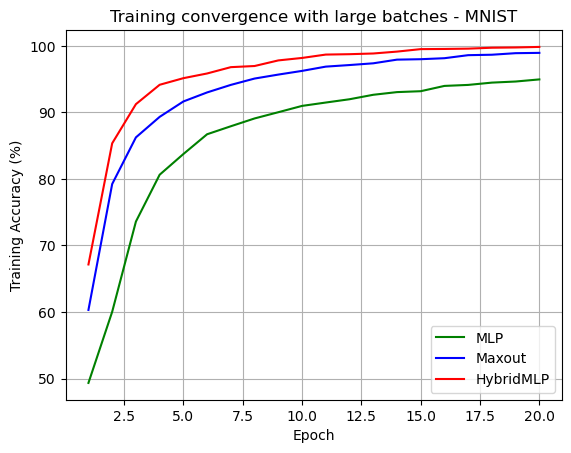

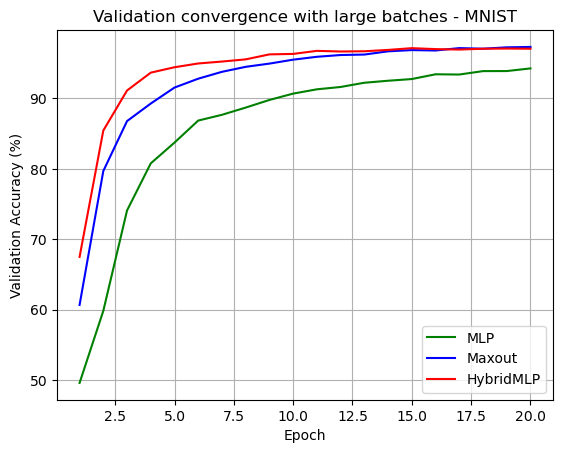

In [139]:
plt.figure()
plt.plot(np.arange(1,21), mlp_train_list, color='green', label='MLP')
plt.plot(np.arange(1,21), maxout_train_list, color='blue', label='Maxout')
plt.plot(np.arange(1,21), hybrid_train_list, color='red', label='HybridMLP')
plt.legend()
plt.grid()
plt.title('Training convergence with large batches - MNIST')
plt.xlabel('Epoch')
plt.ylabel('Training Accuracy (%)')
plt.savefig("training_convergence_mnist.pdf", format='pdf', dpi=1000)
plt.show()

plt.figure()
plt.plot(np.arange(1,21), mlp_val_list, color='green', label='MLP')
plt.plot(np.arange(1,21), maxout_val_list, color='blue', label='Maxout')
plt.plot(np.arange(1,21), hybrid_val_list, color='red', label='HybridMLP')
plt.legend()
plt.grid()
plt.title('Validation convergence with large batches - MNIST')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy (%)')
plt.savefig("validation_convergence_mnist.pdf", format='pdf', dpi=1000)
plt.show()

In [142]:
# Load and preprocess MNIST dataset
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

full_train_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.FashionMNIST(root='./data', train=False, transform=transform, download=True)

# Split train dataset into training and validation sets
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# Data loaders
train_loader = DataLoader(train_dataset, batch_size=6400, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [143]:
# Initialize model, loss function, and optimizer
model = MLP(n_layers=4).to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model, mlp_train_list, mlp_val_list = train(model, criterion, optimizer, train_loader, val_loader, num_epochs=20, return_list=True)

Total number of parameters: 466698
Epoch [1/20], Loss: 1.6862, Train Accuracy: 46.41%, Validation Accuracy: 46.95%
Epoch [2/20], Loss: 1.0355, Train Accuracy: 62.21%, Validation Accuracy: 62.27%
Epoch [3/20], Loss: 0.8372, Train Accuracy: 68.16%, Validation Accuracy: 68.22%
Epoch [4/20], Loss: 0.7098, Train Accuracy: 73.88%, Validation Accuracy: 74.09%
Epoch [5/20], Loss: 0.6228, Train Accuracy: 75.68%, Validation Accuracy: 75.87%
Epoch [6/20], Loss: 0.6041, Train Accuracy: 77.80%, Validation Accuracy: 77.85%
Epoch [7/20], Loss: 0.5450, Train Accuracy: 80.14%, Validation Accuracy: 80.36%
Epoch [8/20], Loss: 0.4988, Train Accuracy: 81.19%, Validation Accuracy: 81.11%
Epoch [9/20], Loss: 0.4805, Train Accuracy: 82.37%, Validation Accuracy: 82.56%
Epoch [10/20], Loss: 0.4623, Train Accuracy: 83.40%, Validation Accuracy: 83.58%
Epoch [11/20], Loss: 0.4501, Train Accuracy: 83.89%, Validation Accuracy: 83.85%
Epoch [12/20], Loss: 0.4389, Train Accuracy: 84.47%, Validation Accuracy: 84.61%
Ep

In [144]:
# Initialize model, loss function, and optimizer
model = Maxout(n_layers=4).to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model, maxout_train_list, maxout_val_list = train(model, criterion, optimizer, train_loader, val_loader, num_epochs=20, return_list=True)

Total number of parameters: 930826
Epoch [1/20], Loss: 0.9445, Train Accuracy: 64.27%, Validation Accuracy: 64.22%
Epoch [2/20], Loss: 0.6752, Train Accuracy: 74.09%, Validation Accuracy: 74.42%
Epoch [3/20], Loss: 0.6096, Train Accuracy: 78.35%, Validation Accuracy: 78.61%
Epoch [4/20], Loss: 0.5136, Train Accuracy: 80.67%, Validation Accuracy: 81.00%
Epoch [5/20], Loss: 0.4911, Train Accuracy: 82.45%, Validation Accuracy: 82.69%
Epoch [6/20], Loss: 0.4503, Train Accuracy: 83.82%, Validation Accuracy: 83.98%
Epoch [7/20], Loss: 0.4176, Train Accuracy: 85.12%, Validation Accuracy: 84.94%
Epoch [8/20], Loss: 0.4050, Train Accuracy: 85.45%, Validation Accuracy: 85.15%
Epoch [9/20], Loss: 0.4171, Train Accuracy: 86.41%, Validation Accuracy: 85.96%
Epoch [10/20], Loss: 0.3409, Train Accuracy: 86.78%, Validation Accuracy: 86.27%
Epoch [11/20], Loss: 0.3523, Train Accuracy: 86.89%, Validation Accuracy: 86.30%
Epoch [12/20], Loss: 0.3242, Train Accuracy: 87.31%, Validation Accuracy: 86.56%
Ep

In [145]:
# Initialize model, loss function, and optimizer
model = HybridMLP(n_layers=4).to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model, hybrid_train_list, hybrid_val_list = train(model, criterion, optimizer, train_loader, val_loader, num_epochs=20, return_list=True)

Total number of parameters: 796938
Epoch [1/20], Loss: 1.0494, Train Accuracy: 72.36%, Validation Accuracy: 72.95%
Epoch [2/20], Loss: 0.6043, Train Accuracy: 80.11%, Validation Accuracy: 80.37%
Epoch [3/20], Loss: 0.4952, Train Accuracy: 83.08%, Validation Accuracy: 82.82%
Epoch [4/20], Loss: 0.4584, Train Accuracy: 85.12%, Validation Accuracy: 84.28%
Epoch [5/20], Loss: 0.4168, Train Accuracy: 86.72%, Validation Accuracy: 85.97%
Epoch [6/20], Loss: 0.3623, Train Accuracy: 87.51%, Validation Accuracy: 86.33%
Epoch [7/20], Loss: 0.3191, Train Accuracy: 88.69%, Validation Accuracy: 87.38%
Epoch [8/20], Loss: 0.3010, Train Accuracy: 89.51%, Validation Accuracy: 87.50%
Epoch [9/20], Loss: 0.2797, Train Accuracy: 89.83%, Validation Accuracy: 87.60%
Epoch [10/20], Loss: 0.2695, Train Accuracy: 90.70%, Validation Accuracy: 88.14%
Epoch [11/20], Loss: 0.2636, Train Accuracy: 90.76%, Validation Accuracy: 87.69%
Epoch [12/20], Loss: 0.2642, Train Accuracy: 90.89%, Validation Accuracy: 87.82%
Ep

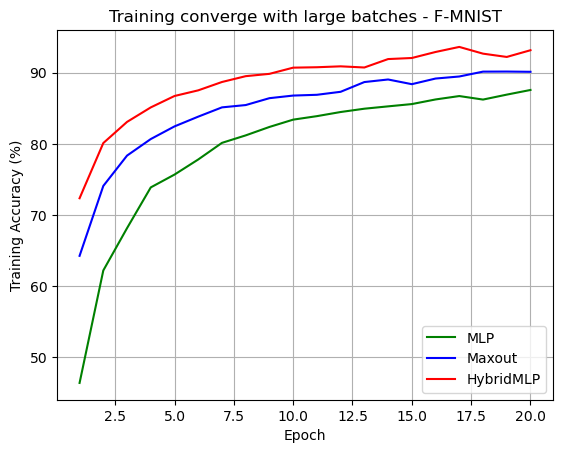

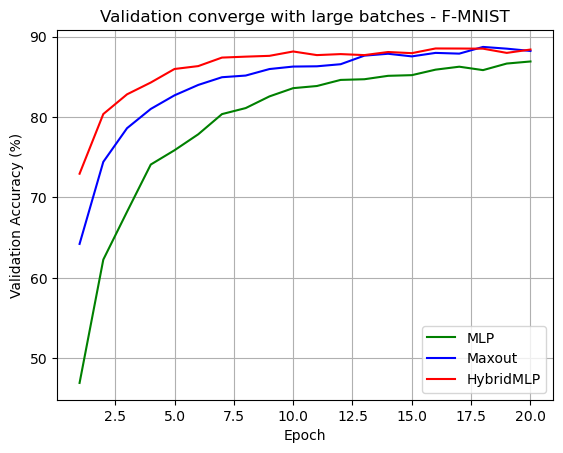

In [146]:
plt.figure()
plt.plot(np.arange(1,21), mlp_train_list, color='green', label='MLP')
plt.plot(np.arange(1,21), maxout_train_list, color='blue', label='Maxout')
plt.plot(np.arange(1,21), hybrid_train_list, color='red', label='HybridMLP')
plt.legend()
plt.grid()
plt.title('Training converge with large batches - F-MNIST')
plt.xlabel('Epoch')
plt.ylabel('Training Accuracy (%)')
plt.savefig("training_convergence_fashion_mnist.pdf", format='pdf', dpi=1000)
plt.show()

plt.figure()
plt.plot(np.arange(1,21), mlp_val_list, color='green', label='MLP')
plt.plot(np.arange(1,21), maxout_val_list, color='blue', label='Maxout')
plt.plot(np.arange(1,21), hybrid_val_list, color='red', label='HybridMLP')
plt.legend()
plt.grid()
plt.title('Validation converge with large batches - F-MNIST')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy (%)')
plt.savefig("validation_convergence_fashion_mnist.pdf", format='pdf', dpi=1000)
plt.show()

In [147]:
# Load and preprocess MNIST dataset
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

full_train_dataset = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, transform=transform, download=True)

# Split train dataset into training and validation sets
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# Data loaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [149]:
# Initialize model, loss function, and optimizer
model = HybridMLP().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 796938
Epoch [1/50], Loss: 2.4558, Train Accuracy: 12.77%, Validation Accuracy: 12.93%
Epoch [2/50], Loss: 1.7562, Train Accuracy: 33.54%, Validation Accuracy: 33.11%
Epoch [3/50], Loss: 1.5862, Train Accuracy: 37.21%, Validation Accuracy: 36.31%
Epoch [4/50], Loss: 2.2517, Train Accuracy: 18.46%, Validation Accuracy: 18.32%
Epoch [5/50], Loss: 2.2545, Train Accuracy: 18.16%, Validation Accuracy: 17.97%
Epoch [6/50], Loss: 1.9395, Train Accuracy: 19.93%, Validation Accuracy: 19.64%
Epoch [7/50], Loss: 5.5857, Train Accuracy: 9.37%, Validation Accuracy: 9.75%
Epoch [8/50], Loss: 1.8058, Train Accuracy: 28.82%, Validation Accuracy: 29.12%
Epoch [9/50], Loss: 1.7276, Train Accuracy: 31.28%, Validation Accuracy: 30.82%
Epoch [10/50], Loss: 53.9505, Train Accuracy: 9.23%, Validation Accuracy: 9.28%
Epoch [11/50], Loss: 2.2065, Train Accuracy: 17.87%, Validation Accuracy: 17.88%
Epoch [12/50], Loss: 2.0736, Train Accuracy: 22.06%, Validation Accuracy: 22.29%
Epoch

In [150]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 37.59%


In [151]:
# Data loaders
train_loader = DataLoader(train_dataset, batch_size=640, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [152]:
# Initialize model, loss function, and optimizer
model = HybridMLP().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 796938
Epoch [1/50], Loss: 0.1909, Train Accuracy: 94.49%, Validation Accuracy: 93.84%
Epoch [2/50], Loss: 0.1689, Train Accuracy: 95.56%, Validation Accuracy: 94.58%
Epoch [3/50], Loss: 0.1973, Train Accuracy: 94.97%, Validation Accuracy: 93.88%
Epoch [4/50], Loss: 0.0983, Train Accuracy: 96.83%, Validation Accuracy: 95.72%
Epoch [5/50], Loss: 0.0451, Train Accuracy: 97.13%, Validation Accuracy: 95.53%
Epoch [6/50], Loss: 0.0836, Train Accuracy: 97.56%, Validation Accuracy: 96.15%
Epoch [7/50], Loss: 0.0981, Train Accuracy: 97.87%, Validation Accuracy: 96.22%
Epoch [8/50], Loss: 0.1092, Train Accuracy: 97.59%, Validation Accuracy: 96.33%
Epoch [9/50], Loss: 0.1113, Train Accuracy: 96.86%, Validation Accuracy: 95.14%
Epoch [10/50], Loss: 0.0863, Train Accuracy: 97.70%, Validation Accuracy: 95.86%
Epoch [11/50], Loss: 0.1605, Train Accuracy: 97.42%, Validation Accuracy: 95.88%
Epoch [12/50], Loss: 0.1090, Train Accuracy: 98.05%, Validation Accuracy: 96.17%
Ep

In [153]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 96.42%


In [154]:
# Data loaders
train_loader = DataLoader(train_dataset, batch_size=6400, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [155]:
# Initialize model, loss function, and optimizer
model = HybridMLP().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 796938
Epoch [1/50], Loss: 1.5013, Train Accuracy: 63.64%, Validation Accuracy: 64.35%
Epoch [2/50], Loss: 0.6591, Train Accuracy: 84.19%, Validation Accuracy: 84.09%
Epoch [3/50], Loss: 0.3544, Train Accuracy: 90.91%, Validation Accuracy: 90.98%
Epoch [4/50], Loss: 0.2758, Train Accuracy: 93.55%, Validation Accuracy: 93.04%
Epoch [5/50], Loss: 0.2056, Train Accuracy: 95.05%, Validation Accuracy: 94.23%
Epoch [6/50], Loss: 0.1544, Train Accuracy: 96.37%, Validation Accuracy: 95.22%
Epoch [7/50], Loss: 0.1239, Train Accuracy: 96.90%, Validation Accuracy: 95.51%
Epoch [8/50], Loss: 0.0979, Train Accuracy: 97.59%, Validation Accuracy: 95.93%
Epoch [9/50], Loss: 0.0765, Train Accuracy: 98.09%, Validation Accuracy: 96.47%
Epoch [10/50], Loss: 0.0679, Train Accuracy: 98.31%, Validation Accuracy: 96.50%
Epoch [11/50], Loss: 0.0536, Train Accuracy: 98.58%, Validation Accuracy: 96.72%
Epoch [12/50], Loss: 0.0542, Train Accuracy: 98.71%, Validation Accuracy: 96.83%
Ep

In [156]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 97.54%


In [157]:
# Load and preprocess MNIST dataset
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

full_train_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.FashionMNIST(root='./data', train=False, transform=transform, download=True)

# Split train dataset into training and validation sets
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# Data loaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [158]:
# Initialize model, loss function, and optimizer
model = HybridMLP().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 796938
Epoch [1/50], Loss: 2.2091, Train Accuracy: 12.31%, Validation Accuracy: 12.61%
Epoch [2/50], Loss: 1.6144, Train Accuracy: 27.62%, Validation Accuracy: 27.95%
Epoch [3/50], Loss: 2.4068, Train Accuracy: 9.80%, Validation Accuracy: 9.57%
Epoch [4/50], Loss: 3.3235, Train Accuracy: 12.16%, Validation Accuracy: 11.87%
Epoch [5/50], Loss: 2.3391, Train Accuracy: 10.45%, Validation Accuracy: 10.80%
Epoch [6/50], Loss: 2.0685, Train Accuracy: 21.82%, Validation Accuracy: 22.05%
Epoch [7/50], Loss: 1.8256, Train Accuracy: 23.82%, Validation Accuracy: 24.22%
Epoch [8/50], Loss: 2.1527, Train Accuracy: 17.12%, Validation Accuracy: 17.16%
Epoch [9/50], Loss: 1.9606, Train Accuracy: 27.22%, Validation Accuracy: 27.67%
Epoch [10/50], Loss: 1.7040, Train Accuracy: 28.68%, Validation Accuracy: 29.31%
Epoch [11/50], Loss: 1.6793, Train Accuracy: 24.97%, Validation Accuracy: 25.45%
Epoch [12/50], Loss: 1.7340, Train Accuracy: 31.79%, Validation Accuracy: 31.78%
Epoc

In [159]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 34.62%


In [160]:
# Data loaders
train_loader = DataLoader(train_dataset, batch_size=640, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [161]:
# Initialize model, loss function, and optimizer
model = HybridMLP().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 796938
Epoch [1/50], Loss: 0.4657, Train Accuracy: 84.76%, Validation Accuracy: 84.15%
Epoch [2/50], Loss: 0.3751, Train Accuracy: 85.64%, Validation Accuracy: 84.67%
Epoch [3/50], Loss: 0.3596, Train Accuracy: 87.95%, Validation Accuracy: 86.53%
Epoch [4/50], Loss: 0.3154, Train Accuracy: 88.91%, Validation Accuracy: 87.28%
Epoch [5/50], Loss: 0.3348, Train Accuracy: 88.69%, Validation Accuracy: 87.11%
Epoch [6/50], Loss: 0.3015, Train Accuracy: 88.90%, Validation Accuracy: 87.13%
Epoch [7/50], Loss: 0.3107, Train Accuracy: 89.58%, Validation Accuracy: 87.48%
Epoch [8/50], Loss: 0.3581, Train Accuracy: 90.05%, Validation Accuracy: 87.26%
Epoch [9/50], Loss: 0.2779, Train Accuracy: 89.71%, Validation Accuracy: 87.23%
Epoch [10/50], Loss: 0.2798, Train Accuracy: 90.68%, Validation Accuracy: 87.85%
Epoch [11/50], Loss: 0.3005, Train Accuracy: 90.54%, Validation Accuracy: 87.84%
Epoch [12/50], Loss: 0.2561, Train Accuracy: 90.37%, Validation Accuracy: 87.55%
Ep

In [162]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 88.11%


In [163]:
# Data loaders
train_loader = DataLoader(train_dataset, batch_size=6400, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [164]:
# Initialize model, loss function, and optimizer
model = HybridMLP().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader)

Total number of parameters: 796938
Epoch [1/50], Loss: 1.1256, Train Accuracy: 69.63%, Validation Accuracy: 70.34%
Epoch [2/50], Loss: 0.6286, Train Accuracy: 79.38%, Validation Accuracy: 79.65%
Epoch [3/50], Loss: 0.4603, Train Accuracy: 83.50%, Validation Accuracy: 83.09%
Epoch [4/50], Loss: 0.4287, Train Accuracy: 85.19%, Validation Accuracy: 84.27%
Epoch [5/50], Loss: 0.3910, Train Accuracy: 86.74%, Validation Accuracy: 86.17%
Epoch [6/50], Loss: 0.3270, Train Accuracy: 87.67%, Validation Accuracy: 86.73%
Epoch [7/50], Loss: 0.3073, Train Accuracy: 89.00%, Validation Accuracy: 87.54%
Epoch [8/50], Loss: 0.3039, Train Accuracy: 89.13%, Validation Accuracy: 87.06%
Epoch [9/50], Loss: 0.2918, Train Accuracy: 90.04%, Validation Accuracy: 87.84%
Epoch [10/50], Loss: 0.2591, Train Accuracy: 90.44%, Validation Accuracy: 88.00%
Epoch [11/50], Loss: 0.2982, Train Accuracy: 90.25%, Validation Accuracy: 87.63%
Epoch [12/50], Loss: 0.2521, Train Accuracy: 90.72%, Validation Accuracy: 88.06%
Ep

In [165]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 88.03%


### Compression experiments

In [ ]:
def prune_weightsMLP(model, pruning_ratio=0.2):
    model = copy.deepcopy(model)  # Clone model to avoid modifying the original

    def prune_layer(layer):
        """Zero out the smallest magnitude weights in 'layer'."""
        with torch.no_grad():
            weight = layer.weight.data
            num_to_prune = int(pruning_ratio * weight.numel())

            # Get absolute values and sort
            flat_weights = weight.abs().flatten()
            threshold = torch.topk(flat_weights, num_to_prune, largest=False).values.max()

            # Zero out weights below the threshold
            weight[weight.abs() <= threshold] = 0.0

    # Apply pruning to all linear layers in the model
    prune_layer(model.fc1)
    for layer in model.fcs:
        prune_layer(layer)
    prune_layer(model.fc2)

    return model  # Return the pruned model

def prune_weightsMPM(model, pruning_ratio=0.2):
    model = copy.deepcopy(model)  # Clone model to avoid modifying the original

    def prune_layer(layer):
        morph_layer, linact = layer[0], layer[1]
        """Zero out the smallest magnitude weights in 'layer'."""
        with torch.no_grad():
            w = morph_layer.w.data
            num_to_prune = int(pruning_ratio * w.numel())

            # Get absolute values and so
            flat_weights = w.abs().flatten()
            threshold = torch.topk(flat_weights, num_to_prune, largest=False).values.max()

            # Zero out weights below the threshold
            w[w.abs() <= threshold] = 0.0

    # Apply pruning to all linear layers in the model
    prune_layer([model.morph_layer1, model.linact1])
    for layer in model.morph_layers:
        prune_layer(layer)
    prune_layer([model.morph_layer2, None])

    return model  # Return the pruned model

In [71]:
# Load and preprocess MNIST dataset
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

full_train_dataset = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, transform=transform, download=True)

# Split train dataset into training and validation sets
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# Data loaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [80]:
# Initialize model, loss function, and optimizer
model = MLP().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader, num_epochs=50)

Total number of parameters: 466698
Epoch [1/50], Loss: 0.2038, Train Accuracy: 94.25%, Validation Accuracy: 93.99%
Epoch [2/50], Loss: 0.1238, Train Accuracy: 95.21%, Validation Accuracy: 94.85%
Epoch [3/50], Loss: 0.2148, Train Accuracy: 96.28%, Validation Accuracy: 95.59%
Epoch [4/50], Loss: 0.1591, Train Accuracy: 96.81%, Validation Accuracy: 95.91%
Epoch [5/50], Loss: 0.0673, Train Accuracy: 97.39%, Validation Accuracy: 96.58%
Epoch [6/50], Loss: 0.0910, Train Accuracy: 97.52%, Validation Accuracy: 96.52%
Epoch [7/50], Loss: 0.0144, Train Accuracy: 98.10%, Validation Accuracy: 97.01%
Epoch [8/50], Loss: 0.0162, Train Accuracy: 97.99%, Validation Accuracy: 96.94%
Epoch [9/50], Loss: 0.0885, Train Accuracy: 98.76%, Validation Accuracy: 97.42%
Epoch [10/50], Loss: 0.0325, Train Accuracy: 98.41%, Validation Accuracy: 97.21%
Epoch [11/50], Loss: 0.0890, Train Accuracy: 98.50%, Validation Accuracy: 97.17%
Epoch [12/50], Loss: 0.0152, Train Accuracy: 98.80%, Validation Accuracy: 97.42%
Ep

In [81]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 97.97%


In [82]:
for pruning_ratio in [0.85, 0.875, 0.9, 0.925, 0.95, 0.975]:
    compressed_model = prune_weightsMLP(model, pruning_ratio)
    print("Pruning ratio:", pruning_ratio)
    test(compressed_model, test_loader)

Pruning ratio: 0.85
Accuracy on the test set: 70.23%
Pruning ratio: 0.875
Accuracy on the test set: 57.79%
Pruning ratio: 0.9
Accuracy on the test set: 25.73%
Pruning ratio: 0.925
Accuracy on the test set: 12.19%
Pruning ratio: 0.95
Accuracy on the test set: 10.09%
Pruning ratio: 0.975
Accuracy on the test set: 9.74%


In [77]:
# Initialize model, loss function, and optimizer
model = MPM().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader, num_epochs=50)

Total number of parameters: 469268
Epoch [1/50], Loss: 0.6923, Train Accuracy: 85.08%, Validation Accuracy: 85.57%
Epoch [2/50], Loss: 0.3896, Train Accuracy: 90.72%, Validation Accuracy: 90.57%
Epoch [3/50], Loss: 0.1969, Train Accuracy: 92.91%, Validation Accuracy: 92.14%
Epoch [4/50], Loss: 0.2740, Train Accuracy: 93.95%, Validation Accuracy: 93.02%
Epoch [5/50], Loss: 0.2258, Train Accuracy: 94.78%, Validation Accuracy: 93.64%
Epoch [6/50], Loss: 0.1226, Train Accuracy: 95.47%, Validation Accuracy: 93.92%
Epoch [7/50], Loss: 0.1581, Train Accuracy: 95.96%, Validation Accuracy: 94.27%
Epoch [8/50], Loss: 0.2066, Train Accuracy: 96.41%, Validation Accuracy: 94.38%
Epoch [9/50], Loss: 0.1853, Train Accuracy: 96.81%, Validation Accuracy: 94.38%
Epoch [10/50], Loss: 0.0655, Train Accuracy: 97.15%, Validation Accuracy: 94.56%
Epoch [11/50], Loss: 0.0262, Train Accuracy: 97.36%, Validation Accuracy: 94.68%
Epoch [12/50], Loss: 0.0858, Train Accuracy: 97.61%, Validation Accuracy: 94.70%
Ep

In [78]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 94.93%


In [79]:
for pruning_ratio in [0.85, 0.875, 0.9, 0.925, 0.95, 0.975]:
    compressed_model = prune_weightsMPM(model, pruning_ratio)
    print("Pruning ratio:", pruning_ratio)
    test(compressed_model, test_loader)

Pruning ratio: 0.85
Accuracy on the test set: 94.33%
Pruning ratio: 0.875
Accuracy on the test set: 94.03%
Pruning ratio: 0.9
Accuracy on the test set: 93.63%
Pruning ratio: 0.925
Accuracy on the test set: 92.16%
Pruning ratio: 0.95
Accuracy on the test set: 90.36%
Pruning ratio: 0.975
Accuracy on the test set: 51.58%


In [83]:
# Load and preprocess MNIST dataset
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

full_train_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.FashionMNIST(root='./data', train=False, transform=transform, download=True)

# Split train dataset into training and validation sets
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# Data loaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [84]:
# Initialize model, loss function, and optimizer
model = MLP().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader, num_epochs=50)

Total number of parameters: 466698
Epoch [1/50], Loss: 0.4085, Train Accuracy: 85.01%, Validation Accuracy: 84.62%
Epoch [2/50], Loss: 0.4393, Train Accuracy: 86.78%, Validation Accuracy: 85.76%
Epoch [3/50], Loss: 0.3284, Train Accuracy: 87.47%, Validation Accuracy: 86.19%
Epoch [4/50], Loss: 0.2432, Train Accuracy: 88.96%, Validation Accuracy: 87.14%
Epoch [5/50], Loss: 0.2828, Train Accuracy: 89.16%, Validation Accuracy: 87.33%
Epoch [6/50], Loss: 0.2359, Train Accuracy: 89.42%, Validation Accuracy: 87.19%
Epoch [7/50], Loss: 0.2407, Train Accuracy: 89.09%, Validation Accuracy: 86.84%
Epoch [8/50], Loss: 0.1349, Train Accuracy: 90.62%, Validation Accuracy: 87.96%
Epoch [9/50], Loss: 0.3850, Train Accuracy: 91.08%, Validation Accuracy: 88.25%
Epoch [10/50], Loss: 0.2290, Train Accuracy: 91.31%, Validation Accuracy: 87.74%
Epoch [11/50], Loss: 0.2807, Train Accuracy: 92.10%, Validation Accuracy: 88.26%
Epoch [12/50], Loss: 0.2501, Train Accuracy: 92.41%, Validation Accuracy: 88.43%
Ep

In [85]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 88.61%


In [86]:
for pruning_ratio in [0.85, 0.875, 0.9, 0.925, 0.95, 0.975]:
    compressed_model = prune_weightsMLP(model, pruning_ratio)
    print("Pruning ratio:", pruning_ratio)
    test(compressed_model, test_loader)

Pruning ratio: 0.85
Accuracy on the test set: 49.78%
Pruning ratio: 0.875
Accuracy on the test set: 28.94%
Pruning ratio: 0.9
Accuracy on the test set: 14.09%
Pruning ratio: 0.925
Accuracy on the test set: 10.75%
Pruning ratio: 0.95
Accuracy on the test set: 10.00%
Pruning ratio: 0.975
Accuracy on the test set: 10.02%


In [87]:
# Initialize model, loss function, and optimizer
model = MPM().to(device)

total_params = 0
for param in model.parameters():
    total_params += param.numel()
print(f"Total number of parameters: {total_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train(model, criterion, optimizer, train_loader, val_loader, num_epochs=50)

Total number of parameters: 469268
Epoch [1/50], Loss: 0.8952, Train Accuracy: 75.89%, Validation Accuracy: 75.68%
Epoch [2/50], Loss: 0.7592, Train Accuracy: 82.89%, Validation Accuracy: 80.93%
Epoch [3/50], Loss: 0.4302, Train Accuracy: 84.93%, Validation Accuracy: 81.80%
Epoch [4/50], Loss: 0.4424, Train Accuracy: 86.67%, Validation Accuracy: 82.22%
Epoch [5/50], Loss: 0.5971, Train Accuracy: 87.94%, Validation Accuracy: 82.53%
Epoch [6/50], Loss: 0.3389, Train Accuracy: 89.06%, Validation Accuracy: 82.70%
Epoch [7/50], Loss: 0.2366, Train Accuracy: 89.98%, Validation Accuracy: 82.69%
Epoch [8/50], Loss: 0.3585, Train Accuracy: 90.49%, Validation Accuracy: 82.97%
Epoch [9/50], Loss: 0.4677, Train Accuracy: 91.38%, Validation Accuracy: 82.69%
Epoch [10/50], Loss: 0.5332, Train Accuracy: 91.96%, Validation Accuracy: 82.92%
Epoch [11/50], Loss: 0.3986, Train Accuracy: 92.52%, Validation Accuracy: 82.78%
Epoch [12/50], Loss: 0.1376, Train Accuracy: 93.18%, Validation Accuracy: 82.92%
Ep

In [88]:
# Testing the model
test(model, test_loader)

Accuracy on the test set: 83.00%


In [89]:
for pruning_ratio in [0.85, 0.875, 0.9, 0.925, 0.95, 0.975]:
    compressed_model = prune_weightsMPM(model, pruning_ratio)
    print("Pruning ratio:", pruning_ratio)
    test(compressed_model, test_loader)

Pruning ratio: 0.85
Accuracy on the test set: 81.43%
Pruning ratio: 0.875
Accuracy on the test set: 81.58%
Pruning ratio: 0.9
Accuracy on the test set: 80.57%
Pruning ratio: 0.925
Accuracy on the test set: 79.31%
Pruning ratio: 0.95
Accuracy on the test set: 74.78%
Pruning ratio: 0.975
Accuracy on the test set: 56.96%
